# DESeq2 with new reference genome
but with pre-filtering! 
# Phase 2 vs. Phase 2

focusing on pairwise comparisons of oysters that experienced both phase 1 and phase 2

## 0. load libraries

In [3]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano) # for volcano plots
library(vegan) # for permanova
library(pheatmap)
library(RColorBrewer)
library(limma) # for removing batch effects

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [6]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts.df <- counts %>%
select(-Gene_ID, -Length)

head(counts.df)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [7]:
# number of genes with 0 counts for all samples
sum(rowSums(counts.df) == 0) # 4884 genes

# pre-filter those rows
counts.filtered <- counts.df[!rowSums(counts.df) == 0,]

# double check this worked
dim(counts.df) # 33903 total genes
dim(counts.filtered) # 29019 genes with at least 1 read

[1] 4884

[1] 33903   120

[1] 29019   120

### meta data
the meta data csv was already generated in [deseq_p1.v.p1](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/deseq_p1.v.p1.ipynb), so just reading in here

In [8]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl("Nu", Sample)) # filter out phase 1 samples - only want phase 2

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

head(meta)
dim(meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


[1] 96  8

creating new column for 'complete' treatment - so I can easily compare phase 1 to phase 2

In [9]:
meta$complete_trtmt <- paste(meta$Phase1_treatment, meta$Phase2_treatment)

# check
head(meta,2)
tail(meta,2)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm


,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
W6_W3_G36,warm,warm,normoxic,6,warm,warm,normoxic,3,warm warm
W6_W4_G48,warm,warm,normoxic,6,warm,warm,normoxic,4,warm warm


In [10]:
# setting the same order for counts matrix and meta data
counts.filtered <- counts.filtered[,rownames(meta)]
all(rownames(meta) == colnames(counts.filtered))

[1] TRUE

## 2a. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [11]:
# tempature treatments
meta$Phase1_temp <- factor(meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

meta$Phase2_temp <- factor(meta$Phase2_temp,
                                   levels = c('ambient', 'warm'))

In [12]:
# DO treatments
meta$Phase1_DO <- factor(meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

meta$Phase2_DO <- factor(meta$Phase2_DO,
                                   levels = c('normoxic', 'hypoxic'))

### complete treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [13]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = counts.filtered,
                              colData = meta,
                              design = ~ complete_trtmt)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



class: DESeqDataSet 
dim: 29019 96 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

looks like there were 29019 genes pre-filter

for the filter, I want to make sure to filter out rows with just one strong signal from one sample (for example, I sometimes see a DEG but at closer look, it is driven by high expression of one sample) 

to do this, i'm going to only keep genes that have a consistent signal (at least 5 reads) in at least 5 samples in at least one treatment treatment combo 

### pre-filter genes 

In [14]:
# filter genes with inconsistent/low reads 
dds$group <- factor(dds$complete_trtmt)

keep <- apply(counts(dds), # raw counts matrix
              1, # apply across rows - for each row/gene, apply this function: 
              function(x) {
  any(tapply(x, dds$group, # split counts for this gene by treatment combo
             function(g) sum(g >= 5) >= 3)) # does this treatment combo have at least 3 samples with counts of 5 or more?
             # any = is at least one group true?
})
dds_filtered <- dds[keep, ]


In [15]:
dds_filtered

class: DESeqDataSet 
dim: 26060 96 
metadata(1): version
assays(4): counts mu H cooks
rownames(26060): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(78): baseMean baseVar ... deviance maxCooks
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

21,663 genes after filtering

In [16]:
26060 / 29019
# so maintaining about 90% of genes

[1] 0.8980323

Checking how strict this filtering was by looking at the control oysters and see how many genes have reasonable counts (not outliers/no counts) 

#### run DESeq again

In [17]:
# run DESeq on the filtered dds object
dds_filtered <- DESeq(dds_filtered)

# run vst on new dds object
vst_mat <- assay(vst(dds_filtered, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [18]:
dim(vst_mat)
head(vst_mat)

[1] 26060    96

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.506739,11.290426,11.274519,11.128664,10.825870,10.807494,11.229752,10.895370,11.007769,11.031302,⋯,11.733793,10.445095,10.946084,11.422612,11.278501,11.089837,11.234382,11.073554,11.706315,11.542363
LOC144621269,8.493607,11.007891,11.445643,10.336375,11.486465,10.494344,12.769196,10.901695,8.233225,8.059534,⋯,13.887492,7.979161,8.067537,10.000519,8.416978,8.785045,13.435455,8.209287,9.643918,13.412882
LOC111120925,8.579916,8.266198,9.701748,8.103600,8.205353,8.079663,7.804871,7.902852,7.804871,7.901232,⋯,9.557409,7.804871,7.990732,9.721694,8.635261,8.328068,8.036248,7.906286,8.137336,8.103365
LOC144621283,9.862385,10.313096,10.337655,10.153495,10.252870,10.549224,10.513537,9.713574,10.077554,10.183225,⋯,9.960665,10.461483,10.193975,10.339949,10.309120,10.220672,9.935887,10.840620,9.951071,9.983954
LOC144621276,13.437845,13.481503,13.655653,13.487925,13.768186,13.890567,13.703314,13.202264,13.746433,13.420767,⋯,14.016282,13.293335,13.840370,13.533890,13.078933,13.265197,13.925498,13.359720,13.406014,13.356125
LOC111115920,8.990057,9.064179,8.956104,8.786534,8.700691,8.644403,8.545452,9.574368,8.749270,9.428388,⋯,8.666097,8.765803,9.260882,8.896594,9.604774,9.607869,9.066350,9.239288,8.726199,8.846351


### explore results and fit

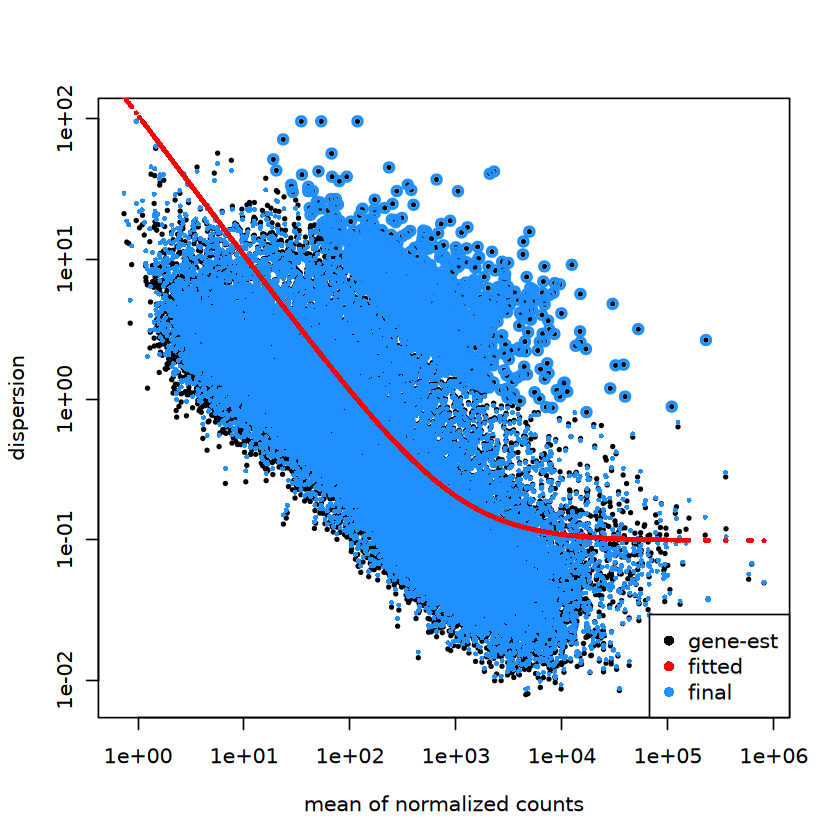

In [19]:
plotDispEsts(dds_filtered)

### nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [20]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,81.17469,84.48860,79.08079,83.95106,82.34655,91.47219,83.49670,83.45295,74.71603,⋯,99.31810,80.23296,70.37641,74.44621,71.35128,74.81232,95.29262,77.84672,76.12725,100.05484
B1_W5_O50,81.17469,0.00000,78.26415,68.56732,64.77855,70.46682,71.67051,82.23779,79.05891,78.36182,⋯,82.11093,86.24772,79.85927,79.98522,82.40868,79.59138,83.94963,81.38642,76.19416,80.50329
B2_B5_O51,84.48860,78.26415,0.00000,86.15990,80.53545,85.46521,82.04571,92.73349,95.80407,92.31772,⋯,87.72215,98.29659,89.80196,77.86505,88.77273,90.94060,88.38233,91.18474,87.02460,83.53047
B2_C4_O40,79.08079,68.56732,86.15990,0.00000,72.32386,70.51130,79.86594,80.24003,82.88784,73.22532,⋯,88.09038,81.39254,77.52661,77.49506,78.39671,76.59543,91.35576,75.68057,60.96719,88.57371
B3_B4_O41,83.95106,64.77855,80.53545,72.32386,0.00000,75.43176,77.50838,87.30230,75.78435,82.20989,⋯,80.15785,89.93878,80.93280,83.62561,87.47606,84.28828,79.88400,84.55540,79.55804,80.52718
B3_C3_O30,82.34655,70.46682,85.46521,70.51130,75.43176,0.00000,82.48342,86.02701,86.42159,81.41093,⋯,91.50152,87.99027,74.19626,83.74453,84.78347,81.06781,94.37442,78.25852,78.76372,92.71638


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,11.491594,12.639810,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-2.333362,-16.608593,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-17.071450,-7.883250,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,6.223148,-7.419990,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-7.832214,-16.339906,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,6.504263,-5.832943,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


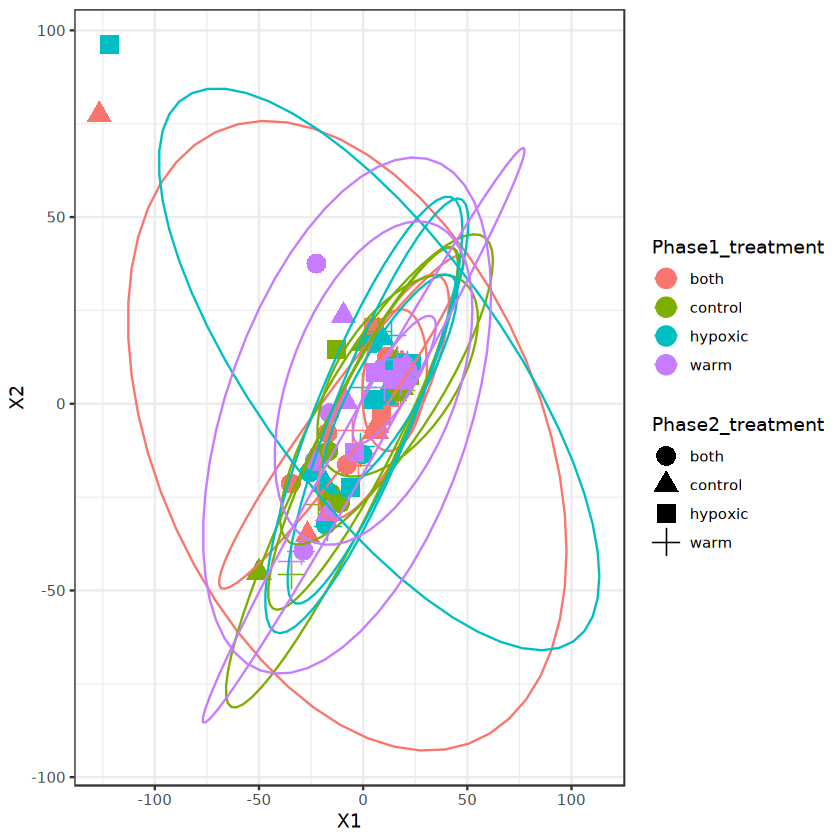

In [21]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

In [22]:
sample_dists <- dist(t(assay(vsd)))  # transpose so samples are rows
head(sample_dists)

meta <- as.data.frame(colData(vsd))
head(meta)

[1] 81.17469 84.48860 79.08079 83.95106 82.34655 91.47219

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [23]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3236.924,0.008307427,0.7930077,0.789
Phase1_DO,1,3376.258,0.008665020,0.8271427,0.733
Phase2_temp,1,8814.911,0.022623088,2.1595475,0.003
Phase2_DO,1,5828.697,0.014959099,1.4279609,0.068
Phase1_temp:Phase1_DO,1,2739.712,0.007031354,0.6711967,0.955
Phase1_temp:Phase2_temp,1,2713.907,0.006965124,0.6648746,0.958
Phase1_DO:Phase2_temp,1,3698.967,0.009493240,0.9062026,0.631
Phase1_temp:Phase2_DO,1,3207.229,0.008231214,0.7857326,0.811
Phase1_DO:Phase2_DO,1,3594.704,0.009225652,0.8806593,0.623


- Phase2_temp has a significant effect on GE (P = 0.004) and explains ~2.2% of the variation in GE
- Phase2_DO also has a significant effect on GE (P = 0.040) and explains ~1.5% of the variance
- The interaction of Phase2_temp and Phase2_DO is significant (P = 0.050) and explains ~1.5% of the variation in GE
    - this means the effect of phase 2 temp depends on the value of phase 2 DO (or vice versa)
- The majoirty of the variation in GE is not explained by the treatments (R2 = 0.84)

### heatmap of sample-to-sample distances using the variance stabilizing transformed values
following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [24]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- dist(t(assay(dds_filtered)))
head(sample_dists)

[1]  559109.0  658789.3  525933.1  551766.8  502959.1 1120977.4

In [25]:
head(vsd)

class: DESeqTransform 
dim: 6 96 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

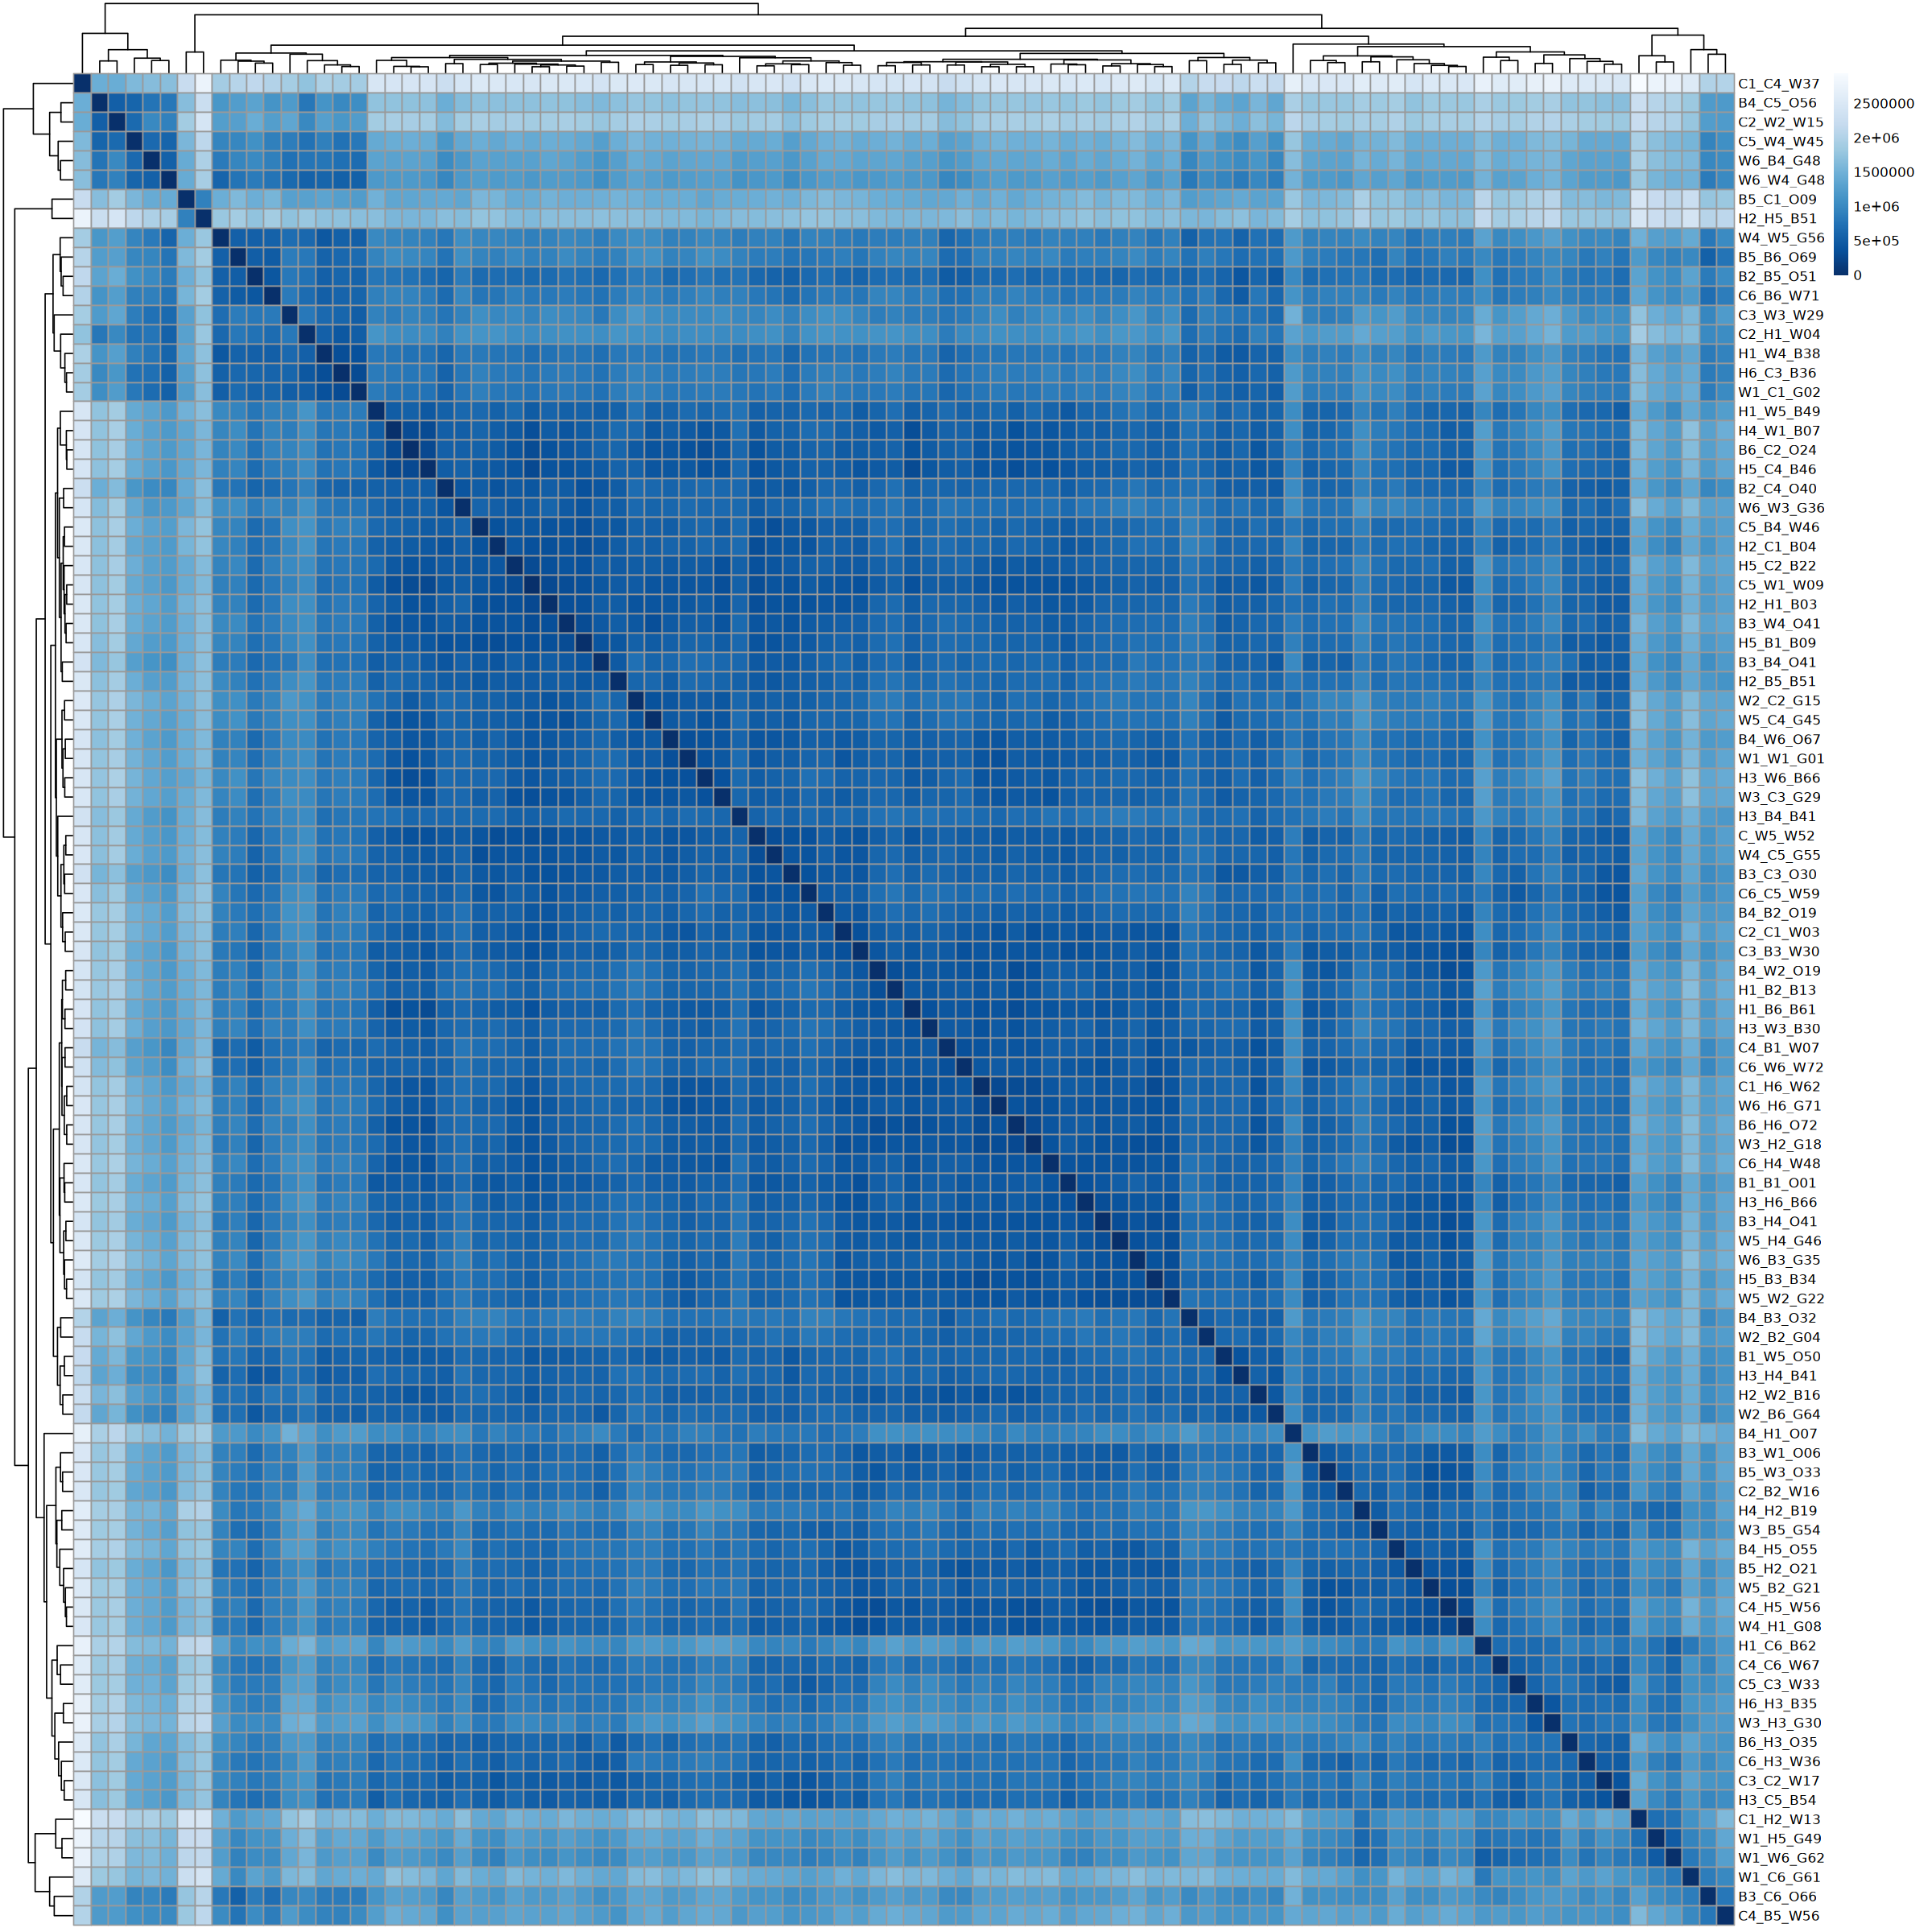

In [26]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

it's weird that there's two samples that are very dissimilar to every other sample, but appear closer together - (HH and BC) - if you look at the nMDS plots too, they look like outliers from their replicates so should consider removing those samples from analysis 

there's those two samples again in the bottom of the plot - B5_C1_O09 and H2_H5_B51 - that cluster away from everything else 

what do things look like if I remove those?

In [27]:
# remove two samples
dds_rm<- dds_filtered[, !colnames(dds_filtered) %in% c("B5_C1_O09", "H2_H5_B51")]

In [28]:
# normalization & transformation
vsd_filtered <- vst(dds_rm)

# calculate sample distances
sample_dists_filtered <- dist(t(assay(vsd_filtered)))
head(sample_dists_filtered)

[1] 80.56880 83.86479 78.49837 83.33886 81.75433 90.81074

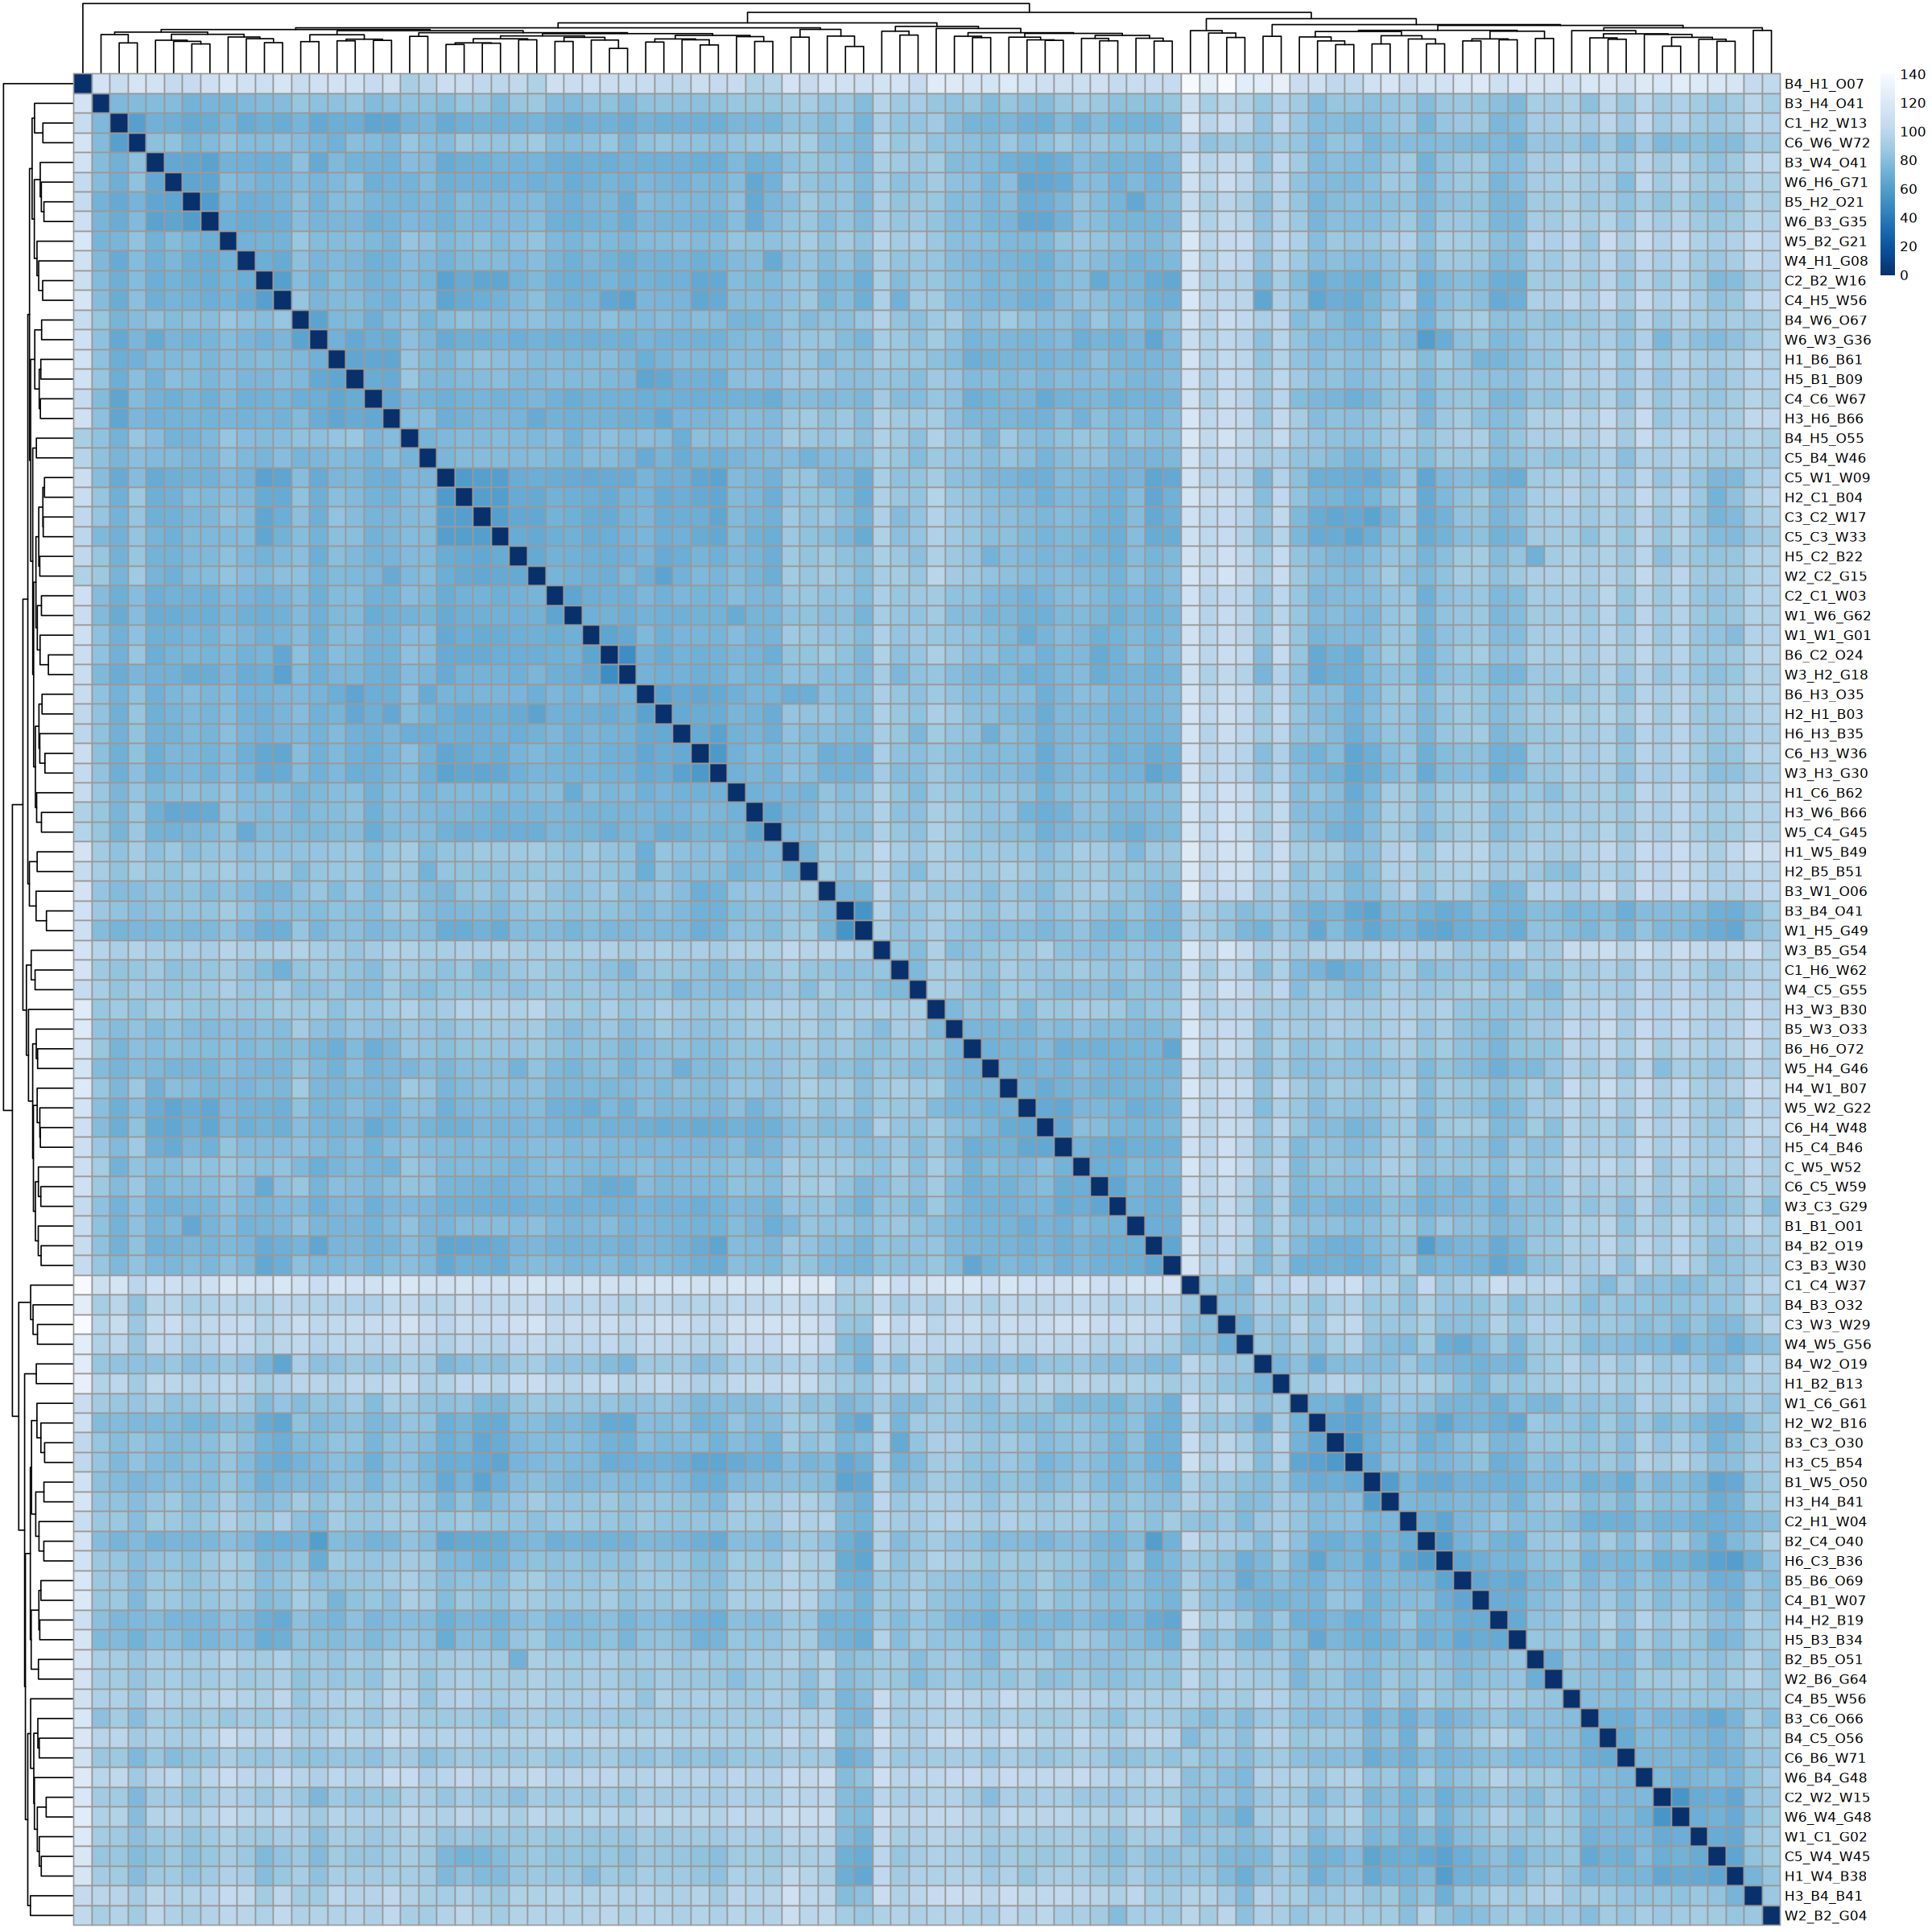

In [29]:
sampleDistMatrix <- as.matrix(sample_dists_filtered)
rownames(sampleDistMatrix) <- paste(colnames(vsd_filtered))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists_filtered,
         clustering_distance_cols = sample_dists_filtered,
         col = colors)

In [30]:
pcaData_filtered <- plotPCA(vsd_filtered, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData_filtered)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.110647,-8.330373,both:both,both,both,B1_B1_O01
B1_W5_O50,12.421904,4.383282,both:warm,both,warm,B1_W5_O50
B2_B5_O51,15.652446,-13.012978,both:both,both,both,B2_B5_O51
B2_C4_O40,2.546170,7.187841,both:control,both,control,B2_C4_O40
B3_B4_O41,15.867706,6.575690,both:both,both,both,B3_B4_O41
B3_C3_O30,1.332008,5.057415,both:control,both,control,B3_C3_O30


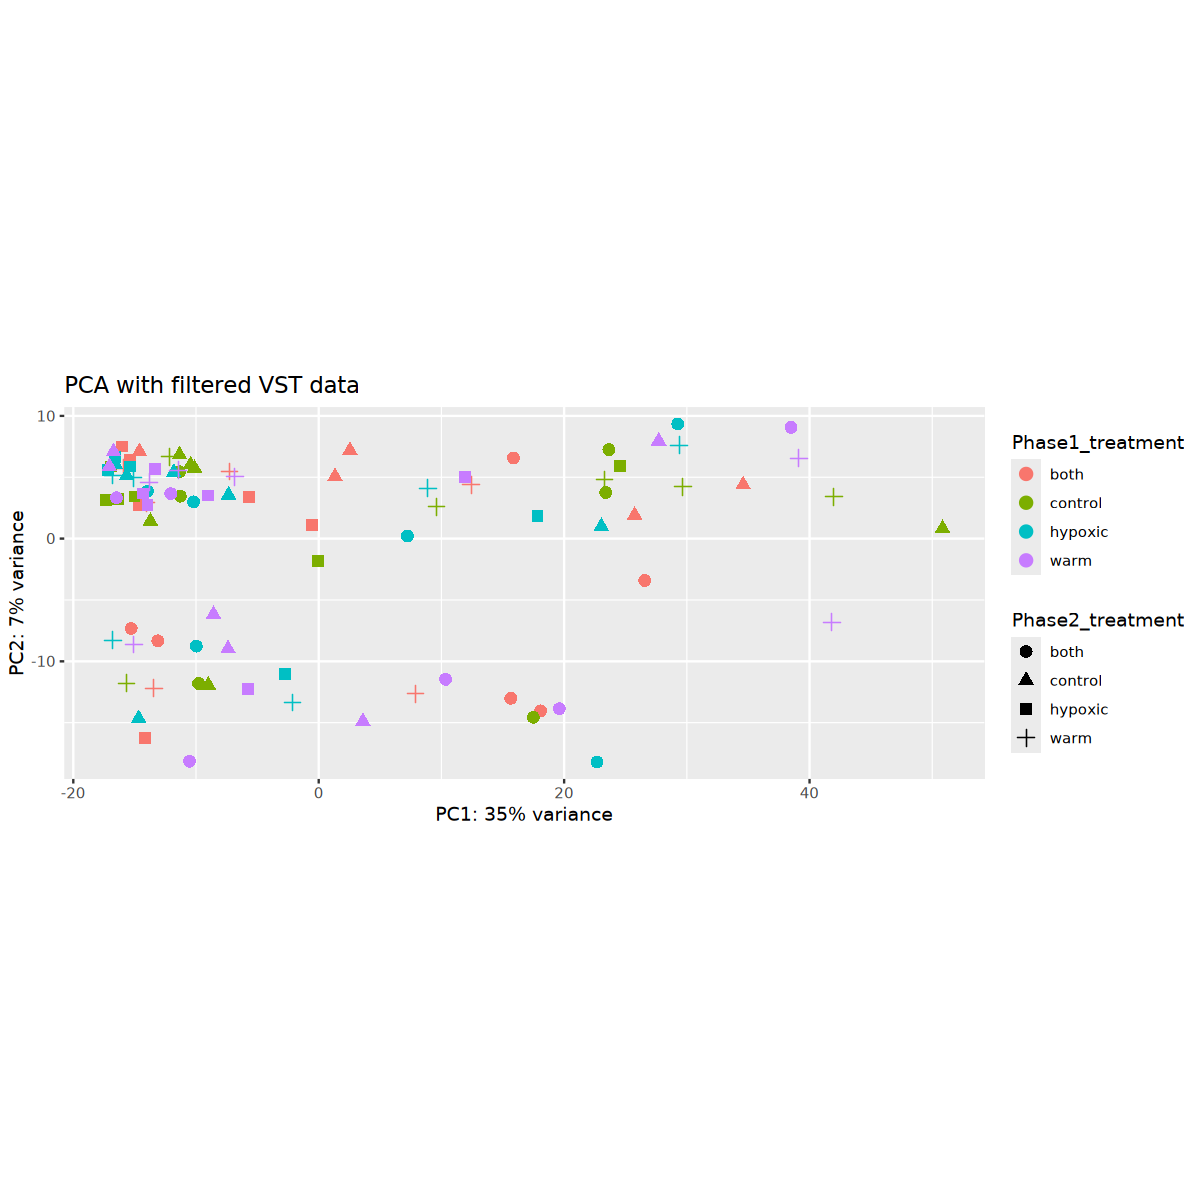

In [31]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData_filtered, "percentVar"))

ggplot(pcaData_filtered, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with filtered VST data")

In [32]:
# calculate MDS value from distance matrix
mdsData_filtered <- data.frame(cmdscale(sample_dists_filtered))
mds_filtered <- cbind(mdsData_filtered, as.data.frame(colData(vsd_filtered))) # combine with sample data
head(mds_filtered)

,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,16.0046465,-8.792288998,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-13.6021237,6.083812880,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-18.8291291,-0.658455087,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-0.9679314,0.006604586,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.3399189,9.290500622,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,0.1441657,15.910793629,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


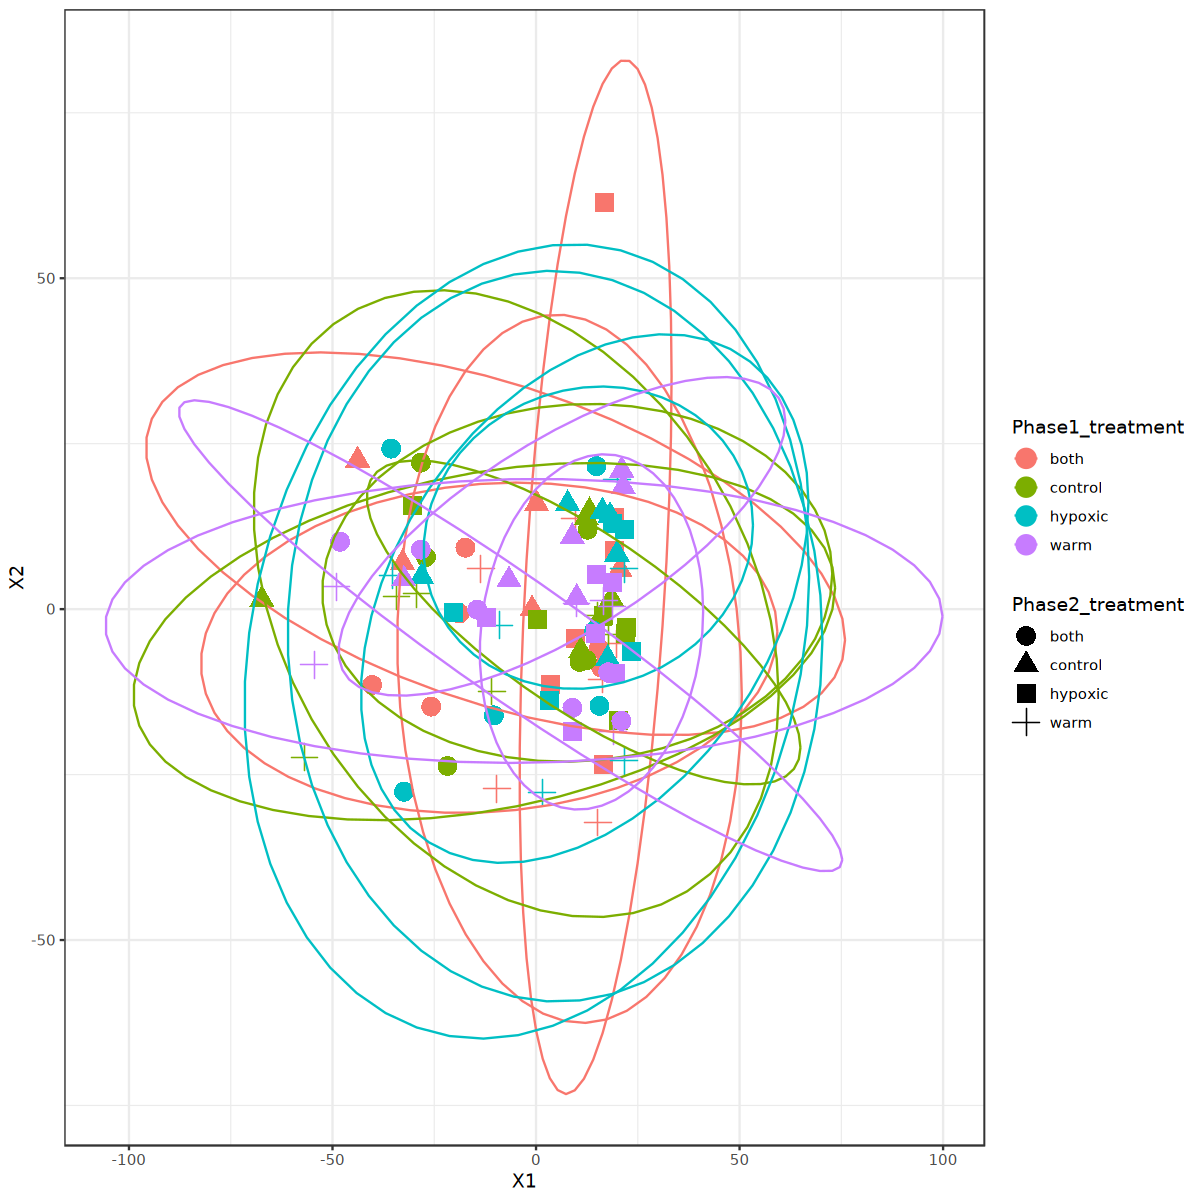

In [33]:
ggplot(mds_filtered, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

okay so it appears when we remove those two seemingly outlier samples, the data gets a little bit 'more clear' and replicates segregate a little better

let's remove those samples (**B5_C1_O09** and **H2_H5_B51**) and re-run DESeq2

## 2b. remove outliers, run DESeq again

In [34]:
outlier_samples <- c('B5_C1_O09', 'H2_H5_B51', 'B4_H1_O07', 'C1_C4_W37')

dds_rm <- dds_filtered[, !colnames(dds_filtered) %in% outlier_samples]
dds_rm <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [35]:
dds_rm

class: DESeqDataSet 
dim: 26060 92 
metadata(1): version
assays(4): counts mu H cooks
rownames(26060): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(78): baseMean baseVar ... deviance maxCooks
colnames(92): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

In [36]:
vsd <- vst(dds_rm, blind = FALSE)
vst_mat <- assay(vsd)
head(vst_mat)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.623469,11.423471,11.408838,11.275151,11.000572,10.984042,11.367711,11.063231,11.165032,11.186417,⋯,11.835304,10.661320,11.109093,11.545469,11.412500,11.239716,11.371961,11.224874,11.809569,11.656580
LOC144621269,9.029866,11.165142,11.566796,10.565749,11.604647,10.704805,12.821577,11.068945,8.822612,8.684961,⋯,13.912374,8.621367,8.691295,10.274234,8.968732,9.263748,13.469161,8.803617,9.970848,13.447100
LOC111120925,9.098889,8.848789,10.019625,8.719850,8.800497,8.700895,8.483578,8.561028,8.483578,8.559747,⋯,9.898177,8.483578,8.630520,10.036487,9.143250,8.897954,8.666530,8.563742,8.746574,8.719664
LOC144621283,10.155971,10.545362,10.566871,10.406314,10.492742,10.753400,10.721783,10.029620,10.340600,10.432119,⋯,10.240015,10.675777,10.441461,10.568882,10.541882,10.464685,10.218781,11.013852,10.231790,10.260001
LOC144621276,13.471496,13.514187,13.684737,13.520469,13.795151,13.915398,13.731482,13.241632,13.773795,13.454805,⋯,14.039092,13.330391,13.866055,13.565448,13.121654,13.302953,13.949750,13.395173,13.440389,13.391663
LOC111115920,9.429854,9.490282,9.402242,9.264949,9.195805,9.150586,9.071305,9.912396,9.234906,9.790446,⋯,9.168003,9.248230,9.651698,9.353947,9.937921,9.940522,9.492055,9.633900,9.216327,9.313269


In [37]:
length(colnames(vst_mat))

[1] 92

In [38]:
#write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/vst_filtered.csv', row.names = TRUE)

In [39]:
meta_noOutliers <- meta[!rownames(meta) %in% outlier_samples, ]

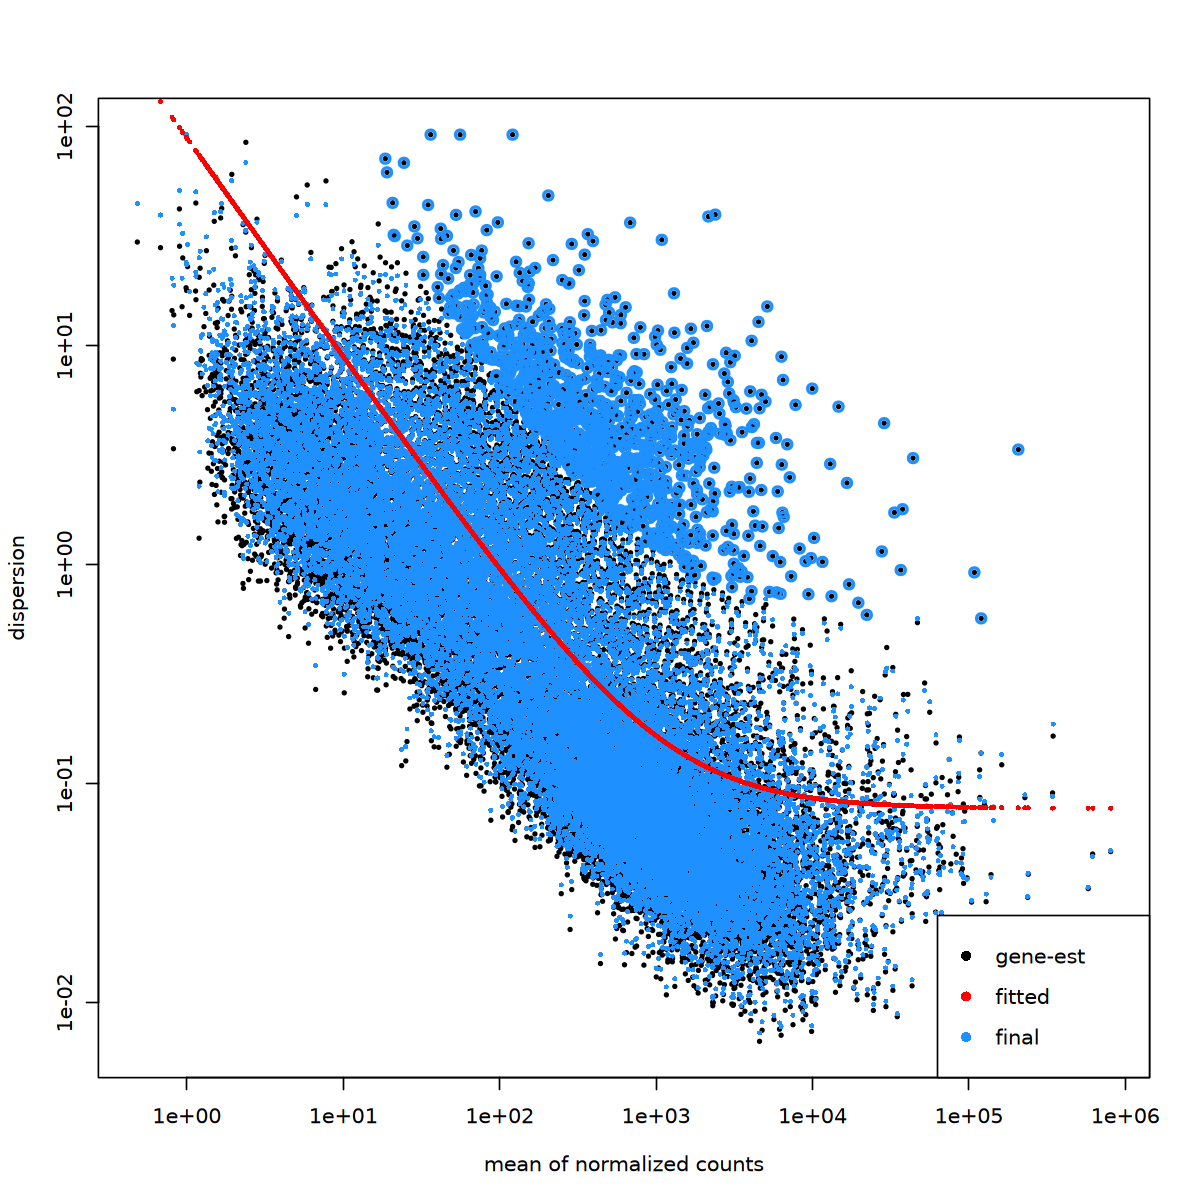

In [40]:
options(repr.plot.height = 10, repr.plot.width = 10)

plotDispEsts(dds_rm)

### nMDS
normalize and transform DESeq object using vst (variance stabilized expression matrix)

In [41]:
# variance stabilizing transformation
vsd <- vst(dds_rm, blind = FALSE)
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.623469,11.423471,11.408838,11.275151,11.000572,10.984042,11.367711,11.063231,11.165032,11.186417,⋯,11.835304,10.661320,11.109093,11.545469,11.412500,11.239716,11.371961,11.224874,11.809569,11.656580
LOC144621269,9.029866,11.165142,11.566796,10.565749,11.604647,10.704805,12.821577,11.068945,8.822612,8.684961,⋯,13.912374,8.621367,8.691295,10.274234,8.968732,9.263748,13.469161,8.803617,9.970848,13.447100
LOC111120925,9.098889,8.848789,10.019625,8.719850,8.800497,8.700895,8.483578,8.561028,8.483578,8.559747,⋯,9.898177,8.483578,8.630520,10.036487,9.143250,8.897954,8.666530,8.563742,8.746574,8.719664
LOC144621283,10.155971,10.545362,10.566871,10.406314,10.492742,10.753400,10.721783,10.029620,10.340600,10.432119,⋯,10.240015,10.675777,10.441461,10.568882,10.541882,10.464685,10.218781,11.013852,10.231790,10.260001
LOC144621276,13.471496,13.514187,13.684737,13.520469,13.795151,13.915398,13.731482,13.241632,13.773795,13.454805,⋯,14.039092,13.330391,13.866055,13.565448,13.121654,13.302953,13.949750,13.395173,13.440389,13.391663
LOC111115920,9.429854,9.490282,9.402242,9.264949,9.195805,9.150586,9.071305,9.912396,9.234906,9.790446,⋯,9.168003,9.248230,9.651698,9.353947,9.937921,9.940522,9.492055,9.633900,9.216327,9.313269


In [42]:
# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,81.05438,84.36473,78.96515,83.82950,82.22897,91.34086,83.37069,83.33753,74.60543,⋯,99.18040,80.11536,70.27711,74.33794,71.24632,74.70062,95.16339,77.73474,76.01661,99.91575
B1_W5_O50,81.05438,0.00000,78.14444,68.46881,64.68388,70.36510,71.56501,82.11807,78.95112,78.24557,⋯,81.99964,86.12387,79.74161,79.86841,82.28850,79.47582,83.83553,81.26913,76.08288,80.38987
B2_B5_O51,84.36473,78.14444,0.00000,86.03586,80.41595,85.33788,81.92405,92.59697,95.66805,92.18366,⋯,87.60077,98.15491,89.66849,77.75370,88.64503,90.80736,88.25958,91.05225,86.89929,83.41549
B2_C4_O40,78.96515,68.46881,86.03586,0.00000,72.22323,70.41162,79.75209,80.12270,82.77844,73.11420,⋯,87.97269,81.27520,77.41400,77.38288,78.28200,76.48491,91.23279,75.57144,60.87540,88.45088
B3_B4_O41,83.82950,64.68388,80.41595,72.22323,0.00000,75.32381,77.39728,87.17872,75.68428,82.09094,⋯,80.04957,89.81285,80.81508,83.50678,87.35314,84.16942,79.77210,84.43673,79.44505,80.41415
B3_C3_O30,82.22897,70.36510,85.33788,70.41162,75.32381,0.00000,82.36413,85.90469,86.30665,81.29381,⋯,91.37605,87.86846,74.08503,83.62610,84.66437,80.95308,94.24608,78.14530,78.65124,92.58801


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,15.510958,14.85234,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-14.624564,-12.18380,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-20.016206,16.47871,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-1.562856,-13.45336,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-18.654898,-11.41609,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,-1.173129,-17.92709,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [43]:
mds$Phase1_treatment <- factor(mds$Phase1_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

mds$Phase2_treatment <- factor(mds$Phase2_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

#### all treatments

Ignoring unknown labels:
• fill : "Phase 1 Treatment"


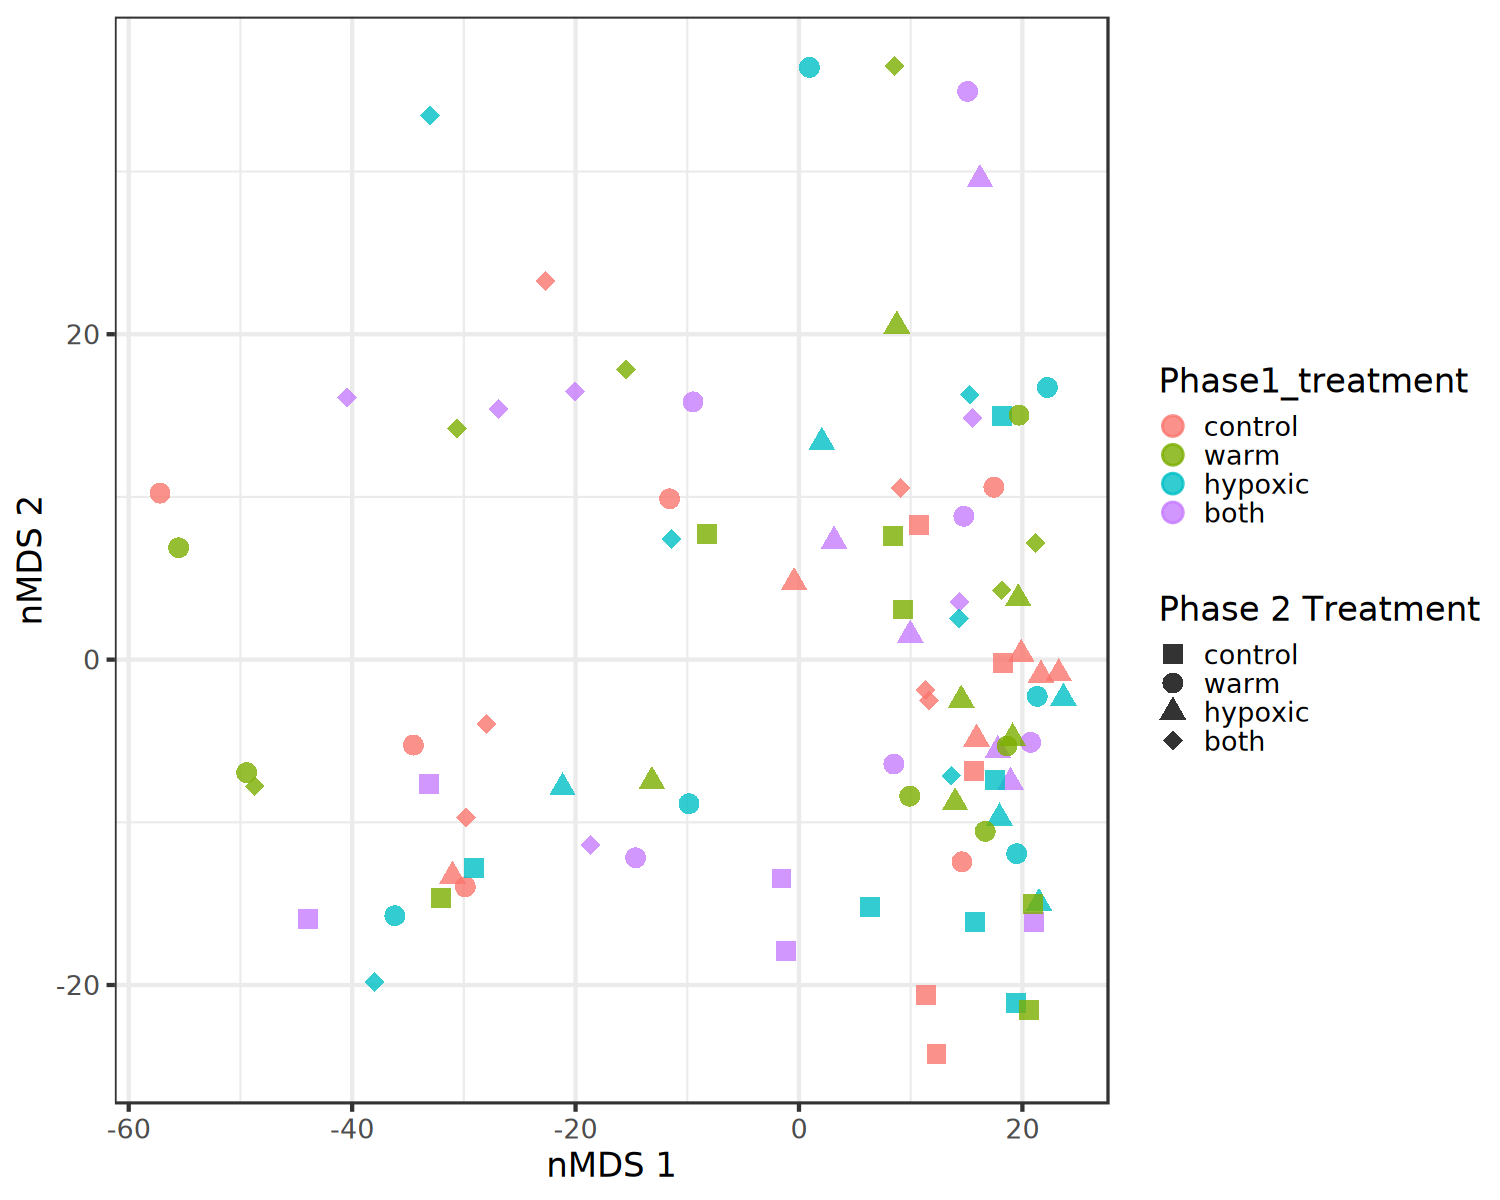

In [44]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(
    size = 5,
    alpha = 0.8,
  ) +
scale_shape_manual(values = c(15, 16, 17,18)) +
# stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'nMDS 1', 
     y = 'nMDS 2',
    fill = 'Phase 1 Treatment',
    shape = 'Phase 2 Treatment')

nmds.plot

#### permANOVA

differences in centroid location(position) between two groups

In [45]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3221.751,0.010034440,0.9276520,0.563
Phase1_DO,1,2675.027,0.008331619,0.7702316,0.900
Phase2_temp,1,9155.971,0.028517117,2.6363168,0.001
Phase2_DO,1,5305.676,0.016525018,1.5276853,0.029
Phase1_temp:Phase1_DO,1,2689.338,0.008376192,0.7743523,0.889
Phase1_temp:Phase2_temp,1,2690.928,0.008381144,0.7748101,0.903
Phase1_DO:Phase2_temp,1,3173.095,0.009882898,0.9136425,0.582
Phase1_temp:Phase2_DO,1,2736.705,0.008523719,0.7879908,0.901
Phase1_DO:Phase2_DO,1,3414.139,0.010633650,0.9830471,0.441


significant effects:
- phase2_temp (2.6% of variance)
- phase2_DO (1.7% of variance)
- phase2_temp:phase2_DO (1.7% of variance)

running with random effects

In [46]:
colnames(meta_noOutliers)

[1] "Phase1_treatment" "Phase1_temp"      "Phase1_DO"        "Phase1_TankRep"  
 [5] "Phase2_treatment" "Phase2_temp"      "Phase2_DO"        "Phase2_TankRep"  
 [9] "complete_trtmt"   "sizeFactor"       "group"

In [47]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO + # fixed effects
        (1|Phase1_TankRep) + (1|Phase2_TankRep), # random effects
        data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3221.751,0.010034440,0.9276520,0.575
Phase1_DO,1,2675.027,0.008331619,0.7702316,0.895
Phase2_temp,1,9155.971,0.028517117,2.6363168,0.001
Phase2_DO,1,5305.676,0.016525018,1.5276853,0.032
Phase1_temp:Phase1_DO,1,2689.338,0.008376192,0.7743523,0.903
Phase1_temp:Phase2_temp,1,2690.928,0.008381144,0.7748101,0.921
Phase1_DO:Phase2_temp,1,3173.095,0.009882898,0.9136425,0.568
Phase1_temp:Phase2_DO,1,2736.705,0.008523719,0.7879908,0.876
Phase1_DO:Phase2_DO,1,3414.139,0.010633650,0.9830471,0.437


still see the same significant effects as the model without the random effects/tank replicates included

reformatting the nmds to look at the sig. effects of phase 2 temp and DO

#### p2 temp and DO 

In [48]:
mds$Phase2_temp <- factor(mds$Phase2_temp, levels = c('ambient', 'warm'))

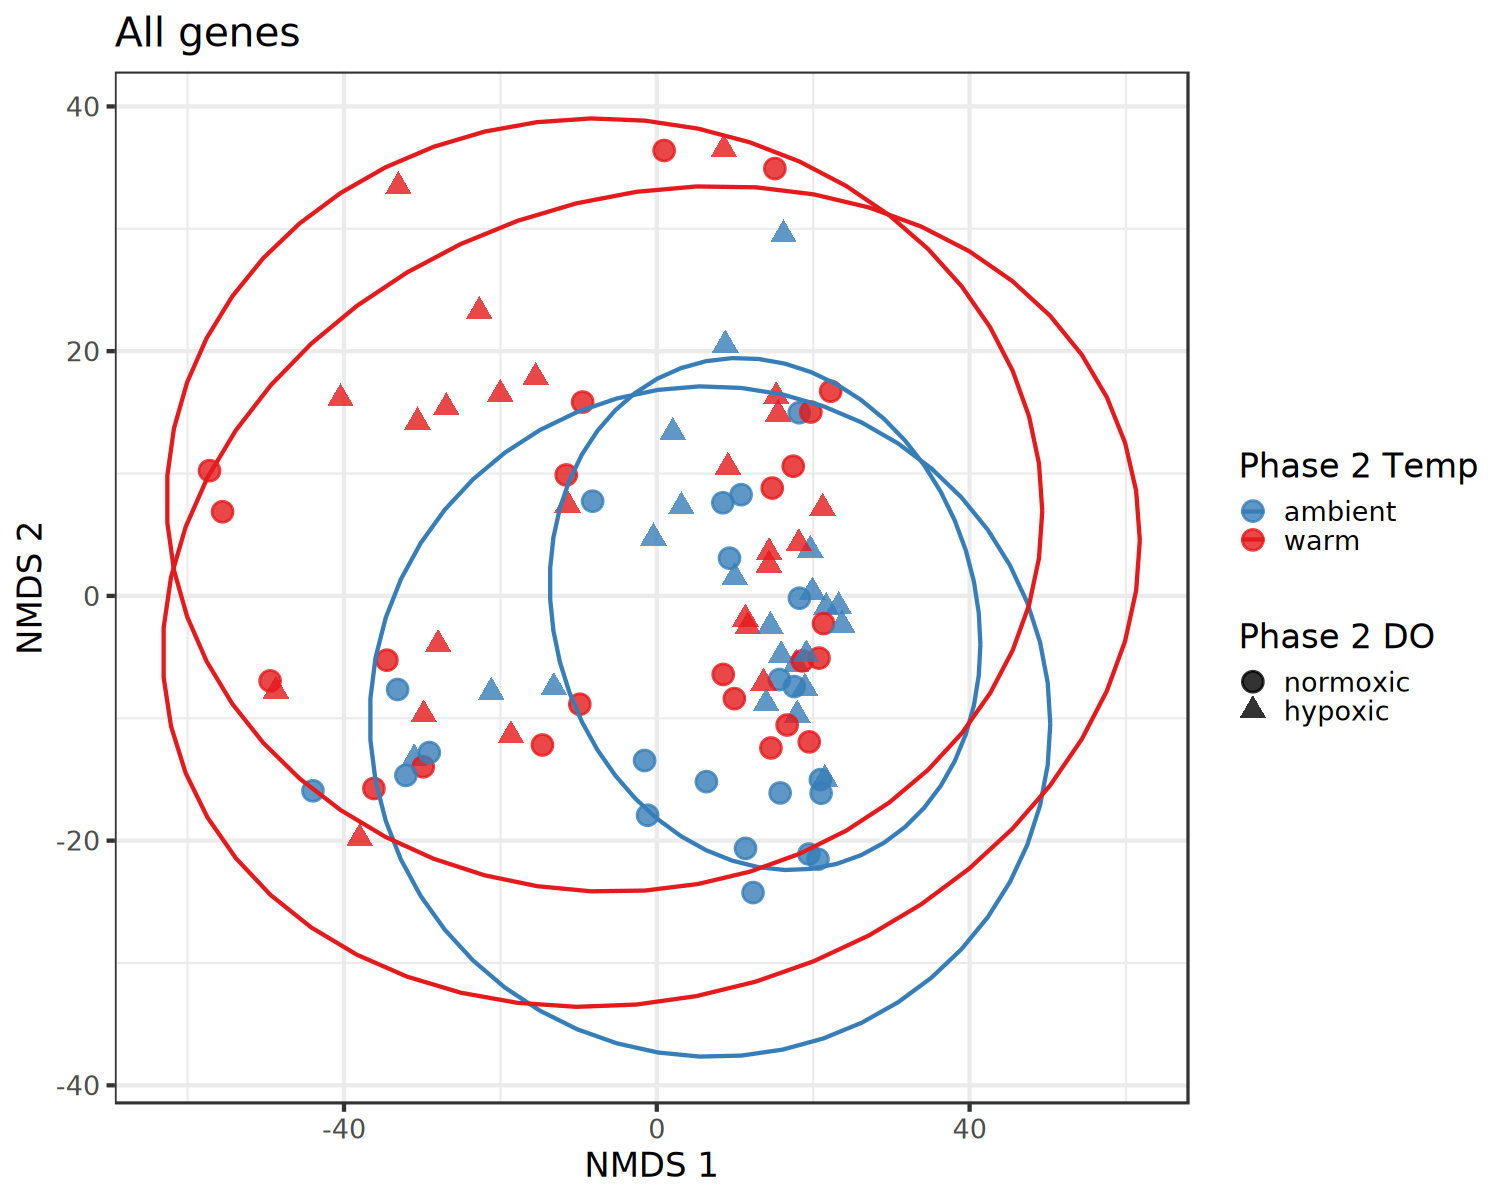

In [49]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase2_temp, shape = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 Temp',
    shape = 'Phase 2 DO',
    title = 'All genes')

nmds.plot2

the blue circles, which are phase 2 warm temp treatment, seem to overlap and have a large dispersion

meanwhile, the red circles, which are phase 2 ambient temp treatment, have some overlap but different dispersion patterns - ambient and hypoxic in phase 2 result in tighter clustering, while ambient and normoxic in phase 2 have wider dispersion

in ambient temperatures, oysters have different transcriptomic profiles depending on the DO treatment. in warm temperatures, the effect of DO is negligible - so warming supersedes DO?

#### just p2 temp

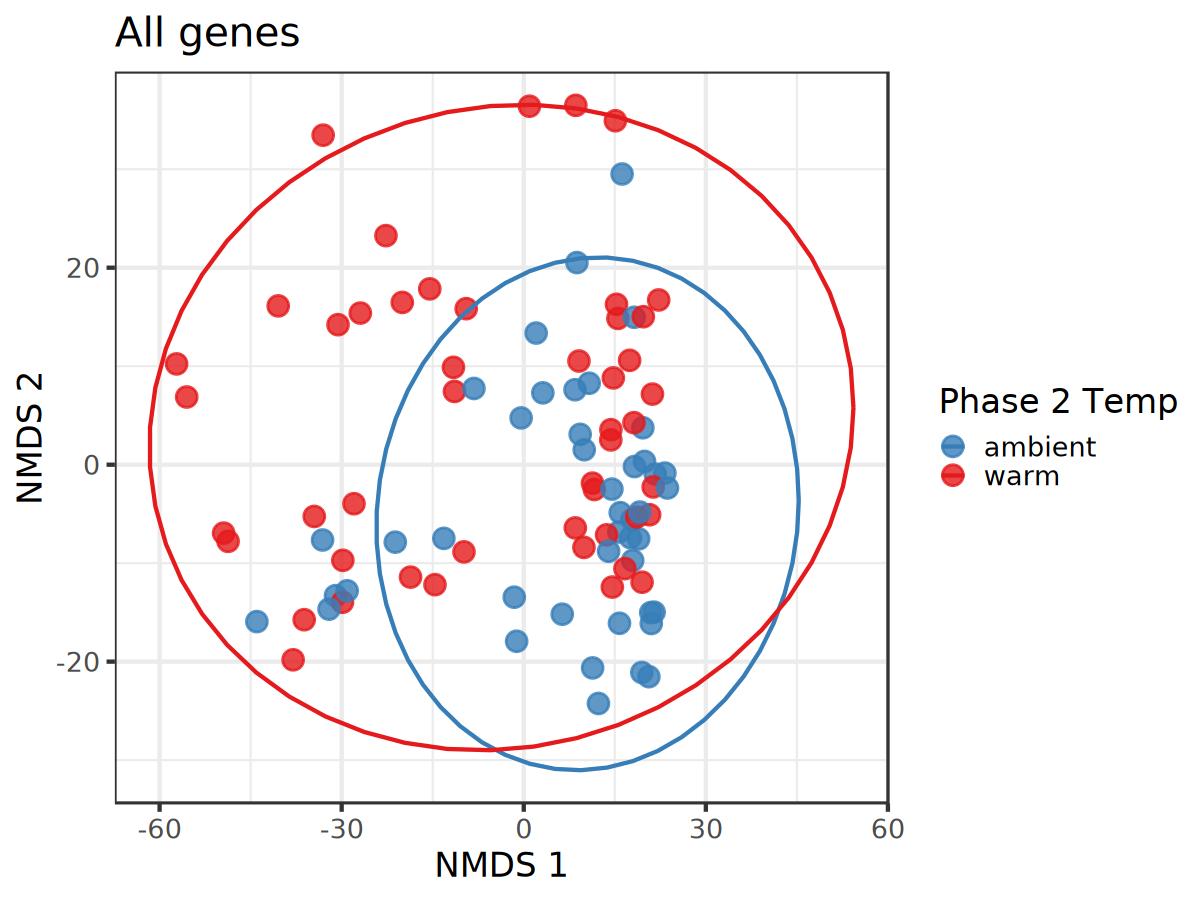

In [50]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase2_temp)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 Temp',
    title = 'All genes')

nmds.plot2

#### just p2 DO

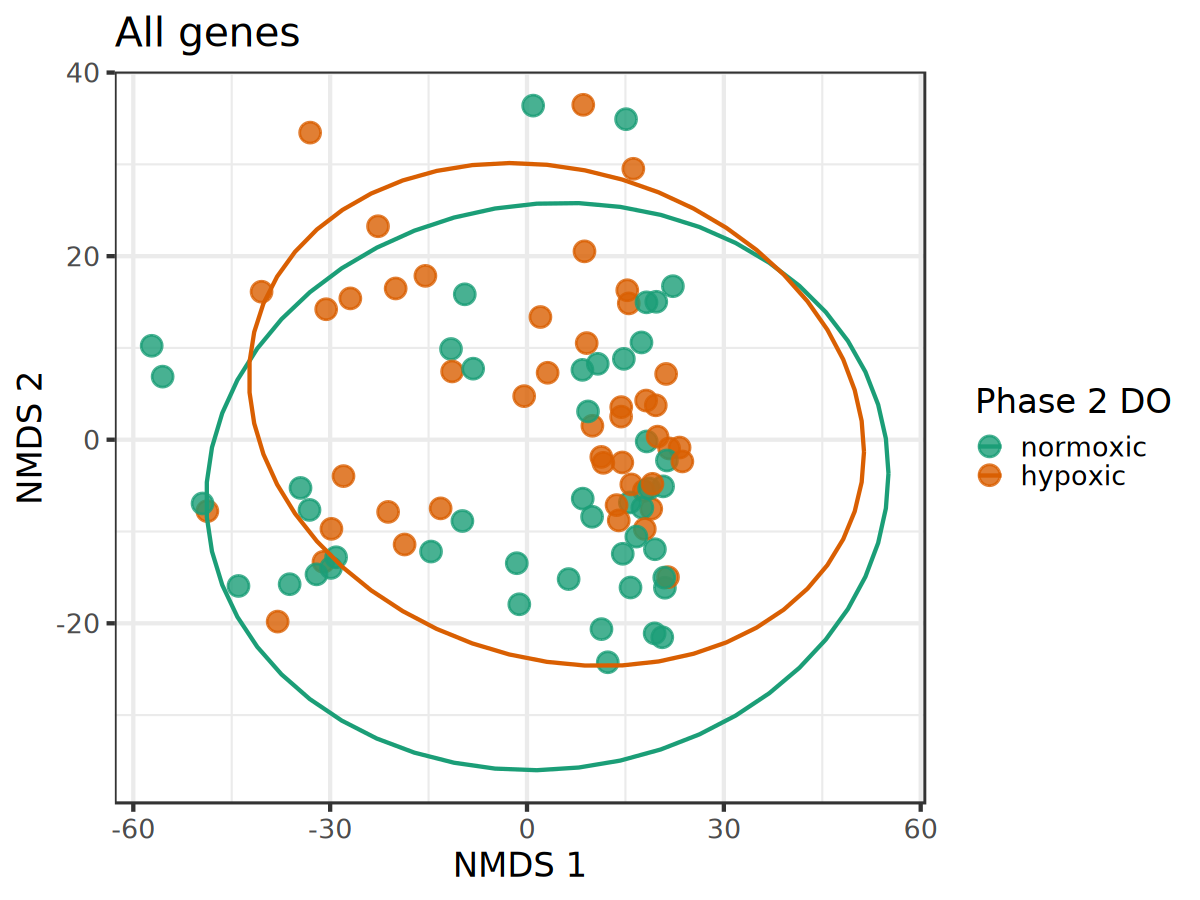

In [51]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Dark2') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 DO',
    title = 'All genes')

nmds.plot2

#### just p1 temp

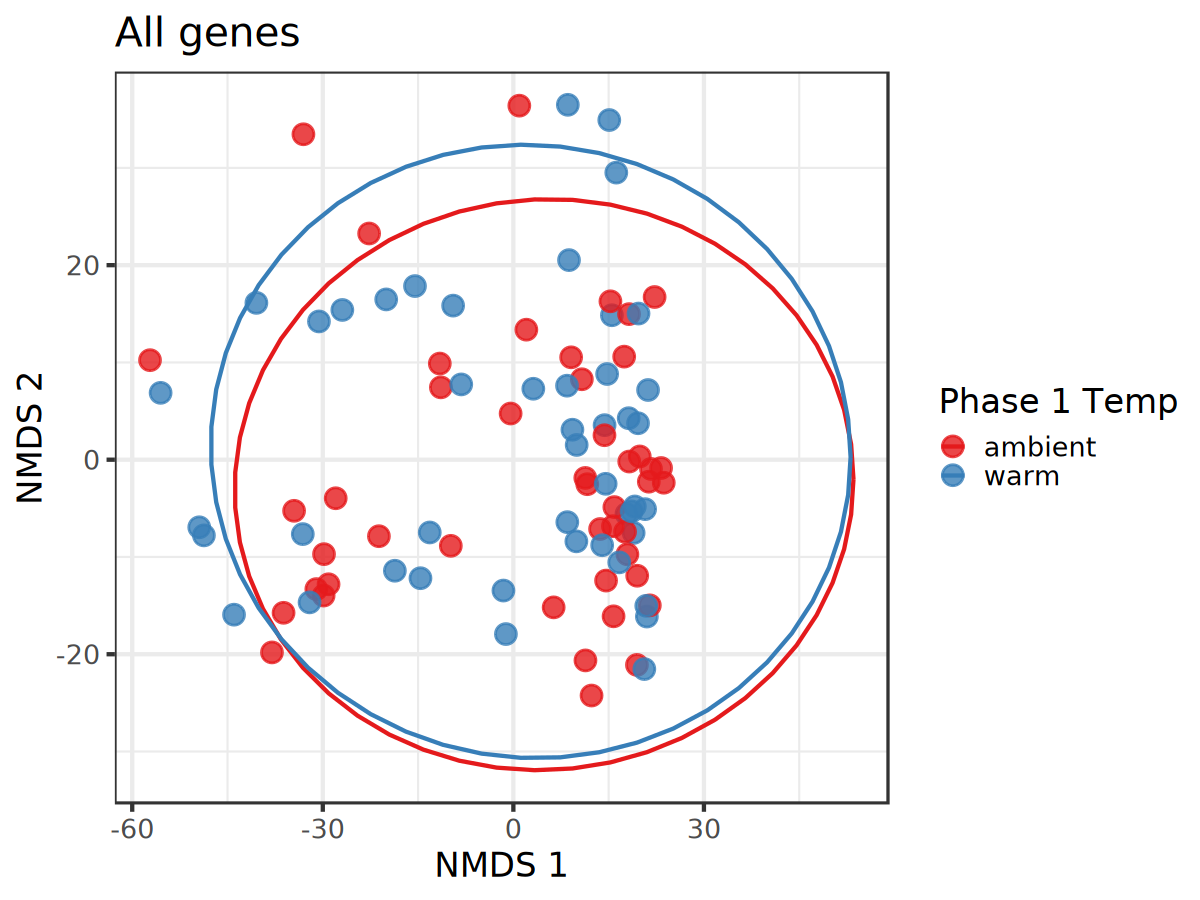

In [52]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase1_temp)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 Temp',
    title = 'All genes')

nmds.plot2

#### just p1 DO

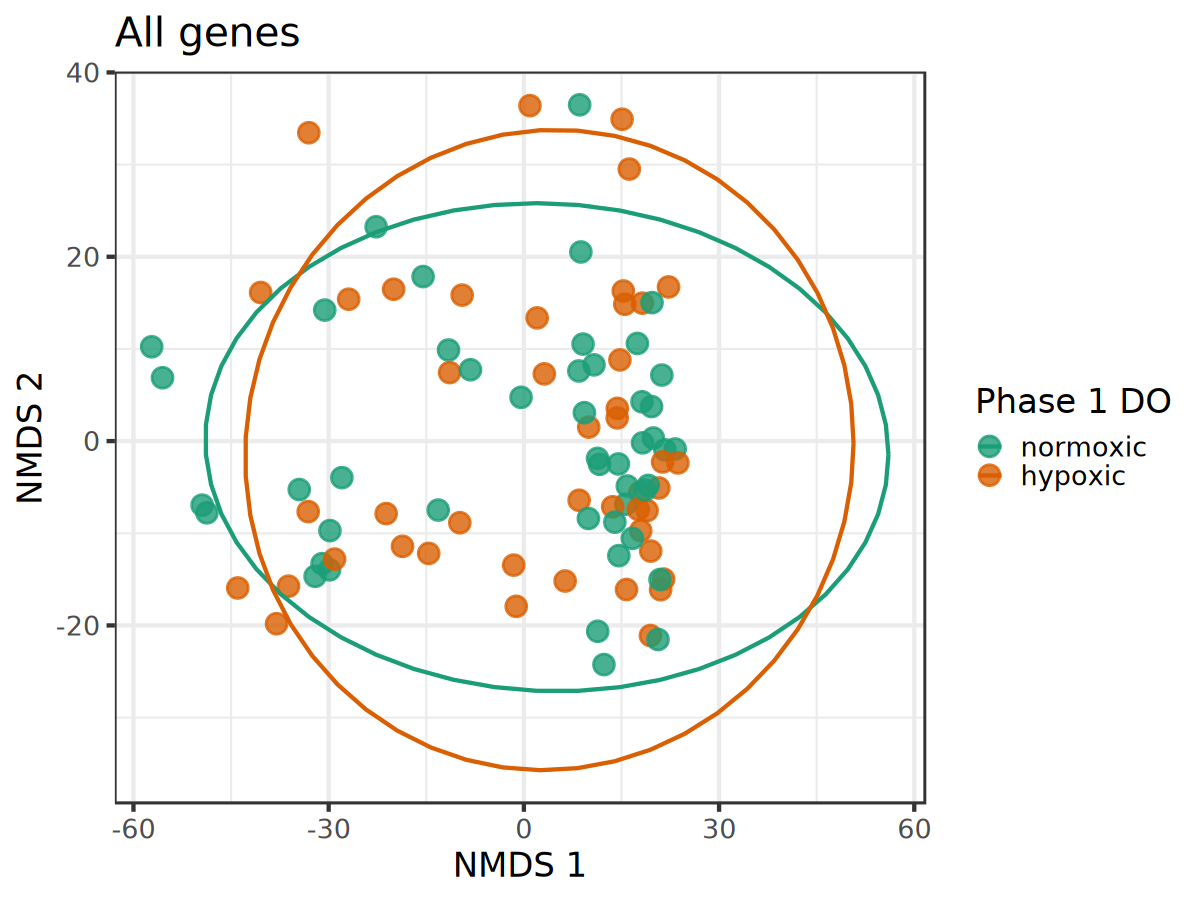

In [53]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase1_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Dark2') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 DO',
    title = 'All genes')

nmds.plot2

### heatmap 
of sample-to-sample distances using the variance stabilizing transformed values


following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [54]:
# normalization & transformation
vsd <- vst(dds_rm, blind = FALSE)

# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 81.05438 84.36473 78.96515 83.82950 82.22897 91.34086

In [55]:
head(vsd)

class: DESeqTransform 
dim: 6 92 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(92): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

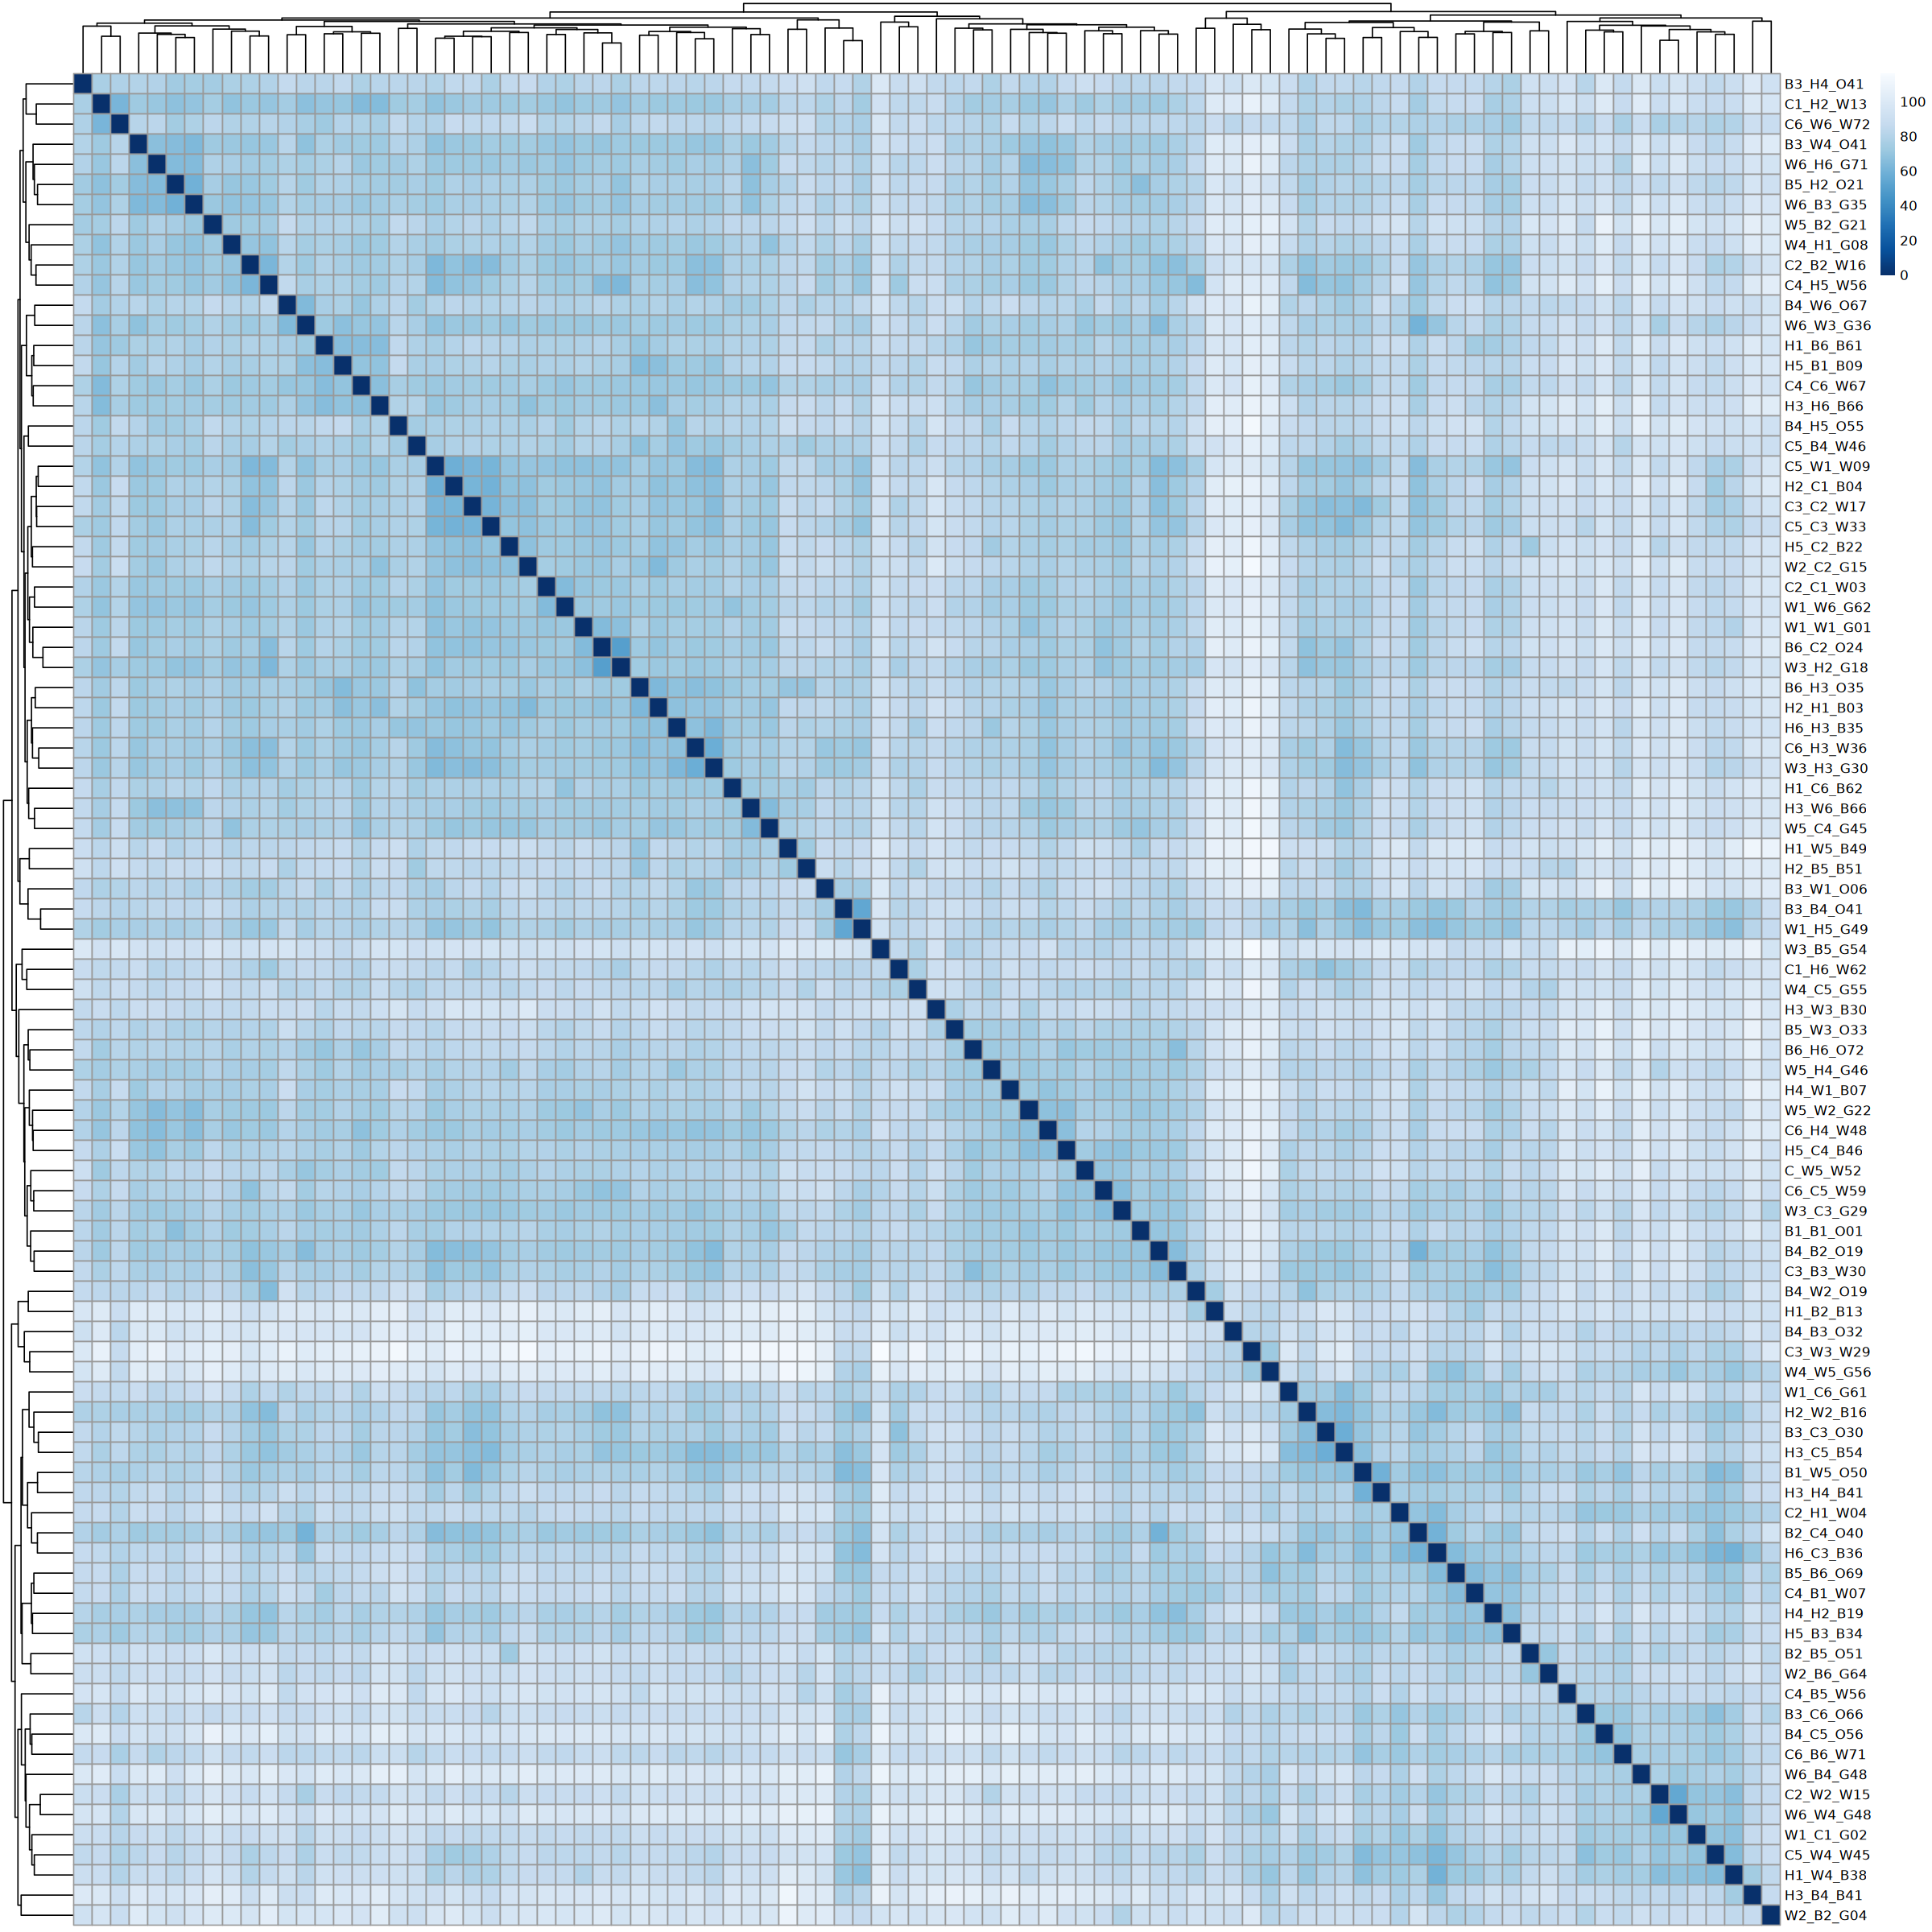

In [56]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

In [57]:
resultsNames(dds_rm)

[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

### MA plot
of one example comparison between HC and CC

In [58]:
# Unshrunken results for your contrast/interaction term
res <- results(dds_rm, contrast = c("complete_trtmt", "hypoxic.control", "control.control"))
# or for an interaction/complex contrast:
# res <- results(dds, name = "phase1stressorA.phase2stressorB")

# Shrunken with ashr — works with contrast= or name= directly, no coef restriction
res_shrunk <- lfcShrink(dds_rm, contrast = c("complete_trtmt", "hypoxic.control", "control.control"), type = "ashr")
# or: res_shrunk <- lfcShrink(dds, res = res, type = "ashr")

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



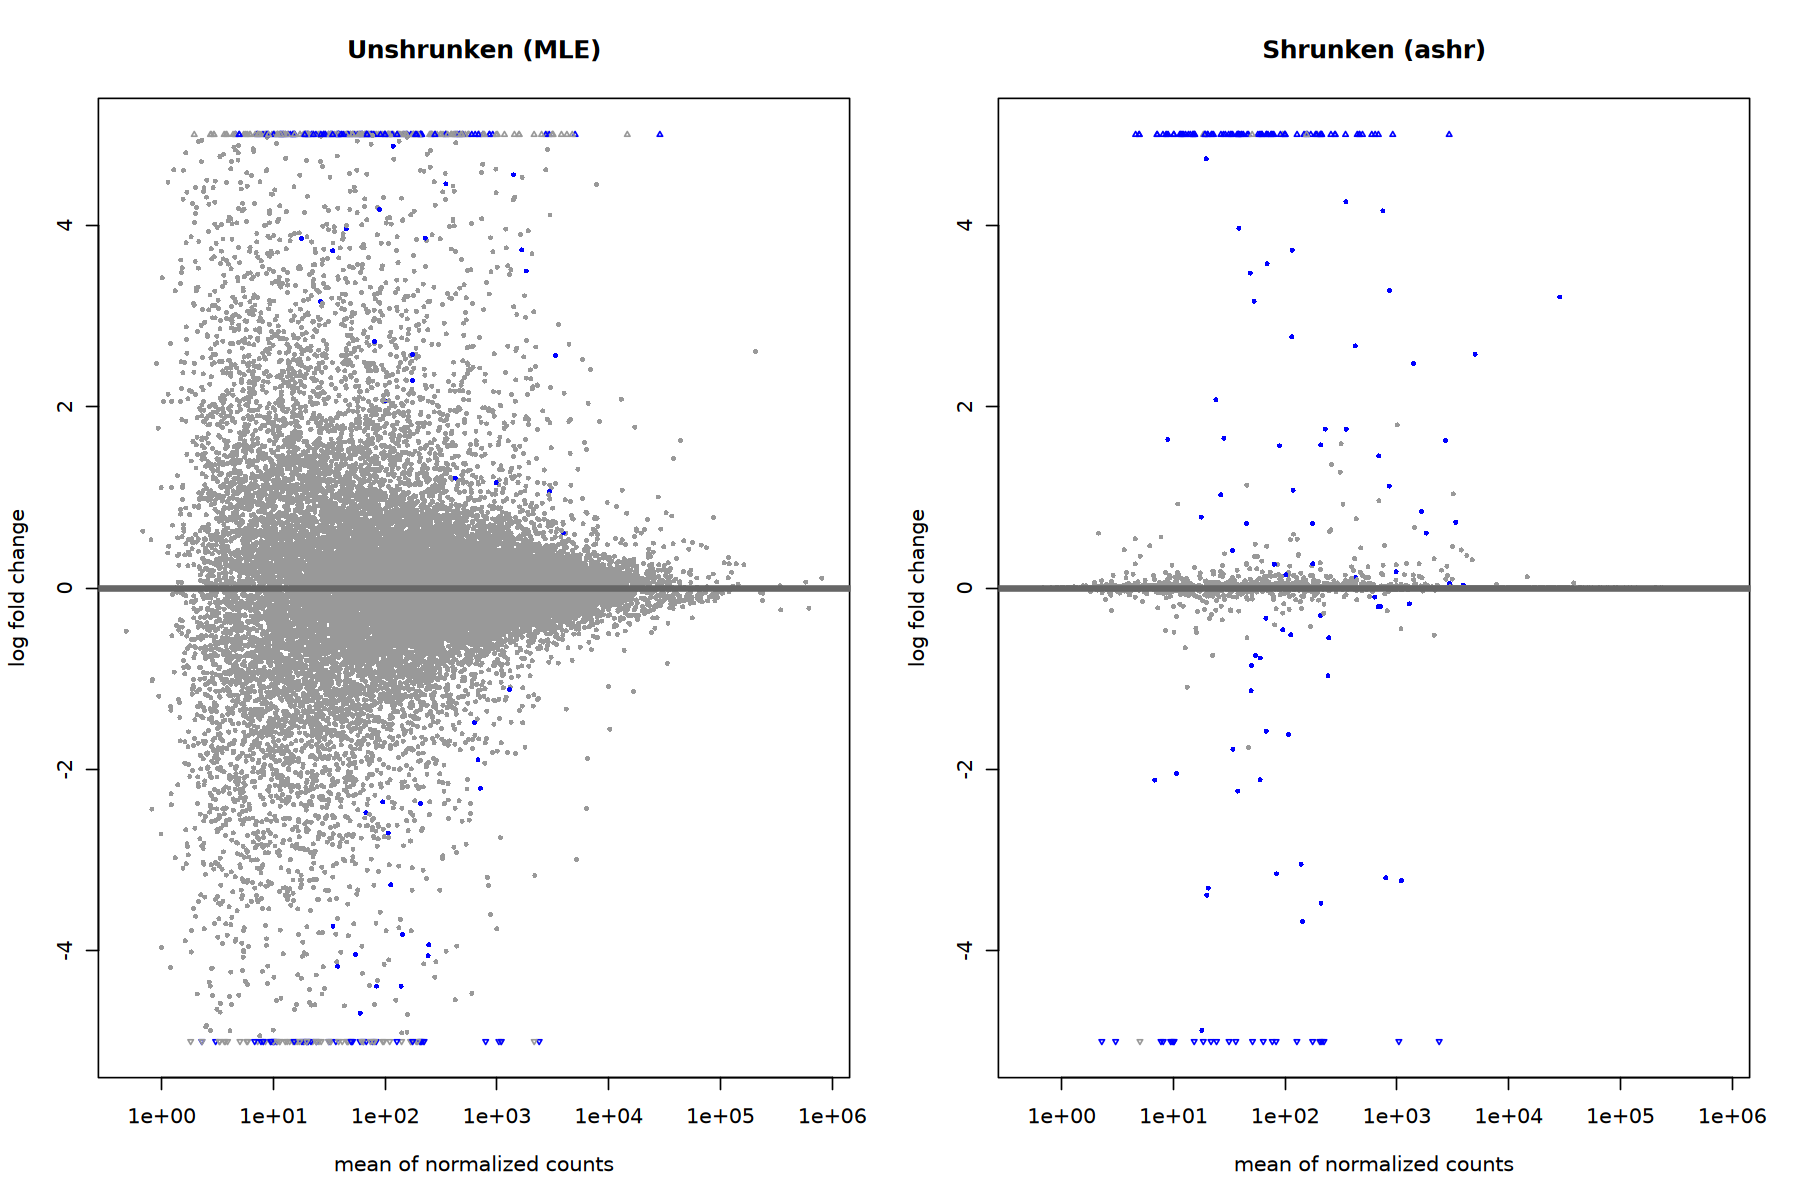

In [59]:
options(repr.plot.height = 10, repr.plot.width = 15)
par(mfrow = c(1, 2))
DESeq2::plotMA(res, ylim = c(-5, 5), main = "Unshrunken (MLE)")
DESeq2::plotMA(res_shrunk, ylim = c(-5, 5), main = "Shrunken (ashr)")

shrinking collapes the grey cloud to LFC = 0, so that genes with large LFC and low mean counts aren't showing up as DEGs (likely due to noise)

this shouldn't change the number of DEGs really - checking below:

In [60]:
sum(res$padj < 0.05, na.rm = TRUE)
sum(res_shrunk$padj < 0.05, na.rm = TRUE)  # should be ~identical to above

# now check with your actual FC cutoff
sum(res_shrunk$padj < 0.05 & abs(res_shrunk$log2FoldChange) > 1, na.rm = TRUE)
sum(res$padj < 0.05 & abs(res$log2FoldChange) > 1, na.rm = TRUE)  # unshrunken FC filter, for comparison

[1] 154

[1] 154

[1] 145

[1] 153

## 3. Pairwise comparisons

### 1. Effect of single exposure on GE after a period of recovery
- CC vs. WC
- CC vs. HC
- CC vs. BC

**CC vs. WC**

In [71]:
options(repr.plot.width = 5, repr.plot.height = 5)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 170, 0.65%
LFC < 0 (down)     : 45, 0.17%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt warm.control vs control.control 
Wald test p-value: complete_trtmt warm.control vs control.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435    5.26347e-05 0.00647939 0.7621780  0.999355
LOC144621269  2097.061    2.00698e-02 0.28425848 0.0388126  0.662144
LOC111120925   132.085   -2.63891e-04 0.05106409 0.8548965  0.999355
LOC144621283   866.810   -5.71421e-05 0.00649576 0.7425560  0.999355
LOC144621276 12195.377    1.45501e-04 0.00625941 0.5049455  0.991065
LOC111115920   171.873    3.81858e-04 0.01740371 0.1993023  0.915563

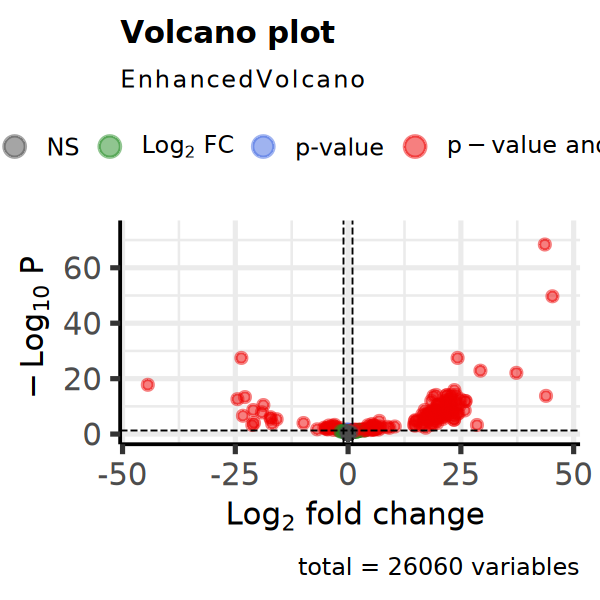

In [72]:
res.wc.cc <- lfcShrink(dds_rm, 
                       contrast= c('complete_trtmt', 'warm.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.wc.cc)

EnhancedVolcano(res.wc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.wc.cc)

In [73]:
write.csv(res.wc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/wc_cc.csv', row.names = FALSE)

**CC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 129, 0.5%
LFC < 0 (down)     : 55, 0.21%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt hypoxic.control vs control.control 
Wald test p-value: complete_trtmt hypoxic.control vs control.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435   -1.25220e-04 0.00675962  0.482856  0.999798
LOC144621269  2097.061    3.48858e-03 0.10781893  0.165626  0.999798
LOC111120925   132.085   -1.97987e-04 0.04612795  0.867173  0.999798
LOC144621283   866.810    2.58096e-05 0.00642145  0.881078  0.999798
LOC144621276 12195.377    1.03560e-04 0.00621262  0.637484  0.999798
LOC111115920   171.873    6.32036e-05 0.00900763  0.700564  0.999798

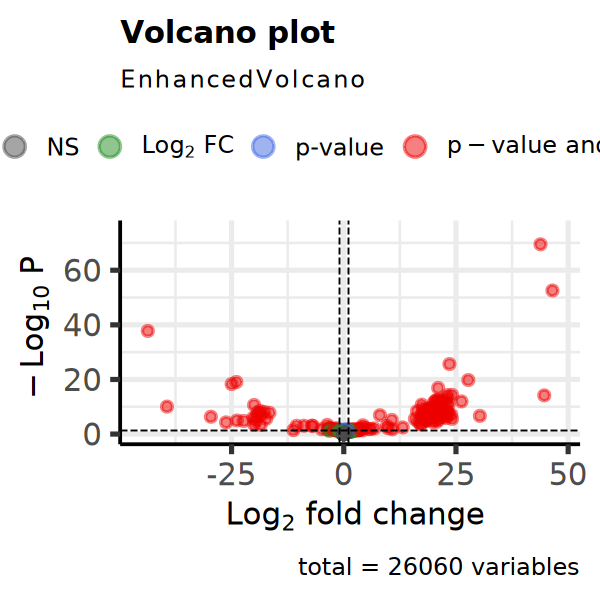

In [74]:
res.hc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.hc.cc)

EnhancedVolcano(res.hc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.hc.cc)

In [75]:
write.csv(res.hc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/hc_cc.csv', row.names = FALSE)

**CC vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 310, 1.2%
LFC < 0 (down)     : 155, 0.59%
outliers [1]       : 79, 0.3%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt both.control vs control.control 
Wald test p-value: complete_trtmt both.control vs control.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE     pvalue      padj
             <numeric>      <numeric>  <numeric>  <numeric> <numeric>
LOC144621260  1949.435   -1.34788e-04 0.00780464 0.52672147  0.980092
LOC144621269  2097.061    3.04231e-01 1.20981517 0.00542861  0.194201
LOC111120925   132.085   -3.72247e-02 0.40067154 0.05478725  0.614296
LOC144621283   866.810    1.03867e-05 0.00703176 0.95825877  0.998496
LOC144621276 12195.377    1.30729e-04 0.00655835 0.55830257  0.983594
LOC111115920   171.873    7.11836e-05 0.01257618 0.82286238  0.998103

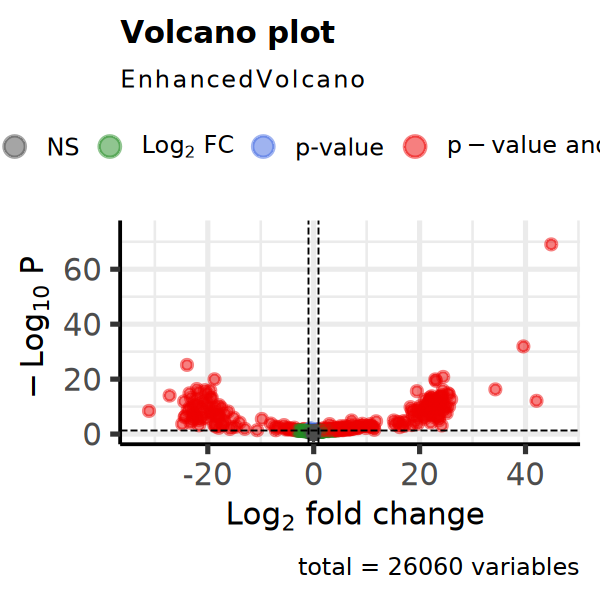

In [76]:
res.bc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.bc.cc)

EnhancedVolcano(res.bc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.bc.cc)

In [77]:
write.csv(res.bc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bc_cc.csv', row.names = FALSE)

### 2. Effect of single exposure experienced only later in life
- CC vs. CW
- CC vs. CH
- CC vs. CB

**CC vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 670, 2.6%
LFC < 0 (down)     : 121, 0.46%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.warm vs control.control 
Wald test p-value: complete_trtmt control.warm vs control.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  1949.435      0.0401376 0.1069693 0.39771670 0.8444643
LOC144621269  2097.061      2.2267502 2.5627733 0.00105743 0.0537635
LOC111120925   132.085     -0.0183764 0.2367132 0.44373889 0.8710827
LOC144621283   866.810     -0.0189366 0.1062007 0.68802795 0.9513560
LOC144621276 12195.377     -0.0149535 0.0970663 0.78287260 0.9718019
LOC111115920   171.873      0.0158250 0.1182082 0.59973011 0.9279844

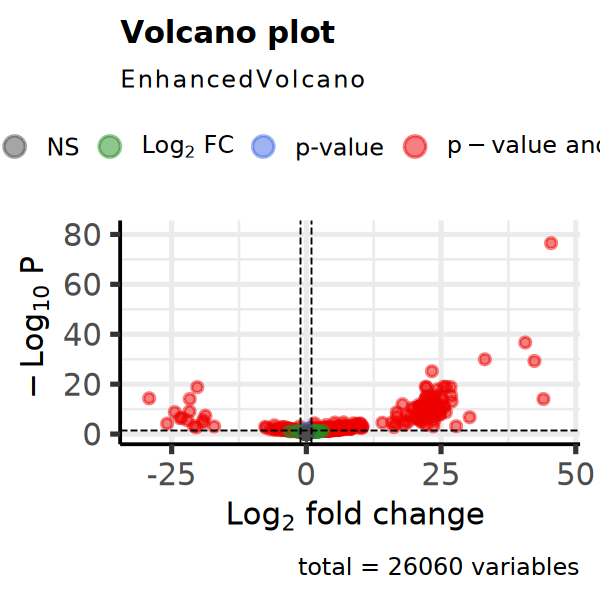

In [78]:
res.cw.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cw.cc)

EnhancedVolcano(res.cw.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cw.cc)

In [79]:
write.csv(res.cw.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/cw_cc.csv', row.names = FALSE)

**CC vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 217, 0.83%
LFC < 0 (down)     : 102, 0.39%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.hypoxic vs control.control 
Wald test p-value: complete_trtmt control.hypoxic vs control.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435     -0.0407561 0.1006665 0.3303126  0.823990
LOC144621269  2097.061      0.0310655 0.2639232 0.0769341  0.568979
LOC111120925   132.085     -0.0275873 0.2603963 0.0961518  0.601771
LOC144621283   866.810     -0.0288830 0.1000621 0.4879938  0.891530
LOC144621276 12195.377     -0.0766654 0.0949509 0.1229649  0.646623
LOC111115920   171.873      0.0104549 0.1086367 0.6837508  0.950815

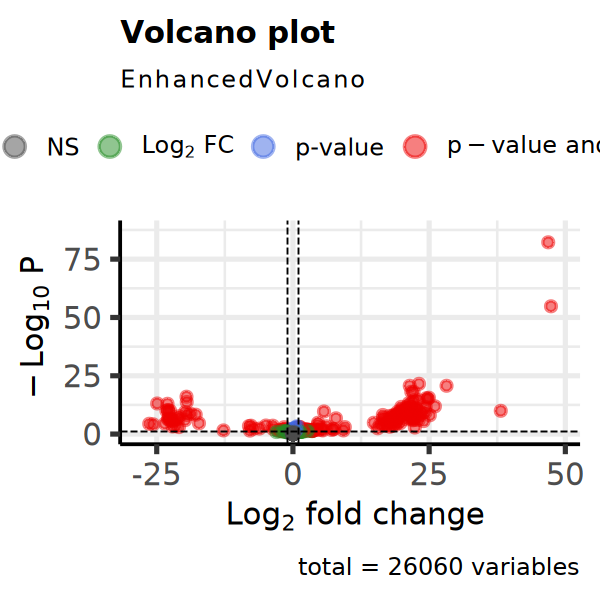

In [80]:
res.ch.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.ch.cc)

EnhancedVolcano(res.ch.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.ch.cc)

In [81]:
write.csv(res.ch.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/ch_cc.csv', row.names = FALSE)

**CC vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 437, 1.7%
LFC < 0 (down)     : 138, 0.53%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.both vs control.control 
Wald test p-value: complete_trtmt control.both vs control.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435     0.00655984  0.126409 0.9221227  0.988448
LOC144621269  2097.061     0.11079184  0.532897 0.0200237  0.284329
LOC111120925   132.085     0.01735160  0.205489 0.4260297  0.850521
LOC144621283   866.810     0.00187806  0.126437 0.9776554  0.997574
LOC144621276 12195.377     0.11186488  0.123372 0.1362254  0.600237
LOC111115920   171.873     0.02530251  0.155135 0.6245612  0.920952

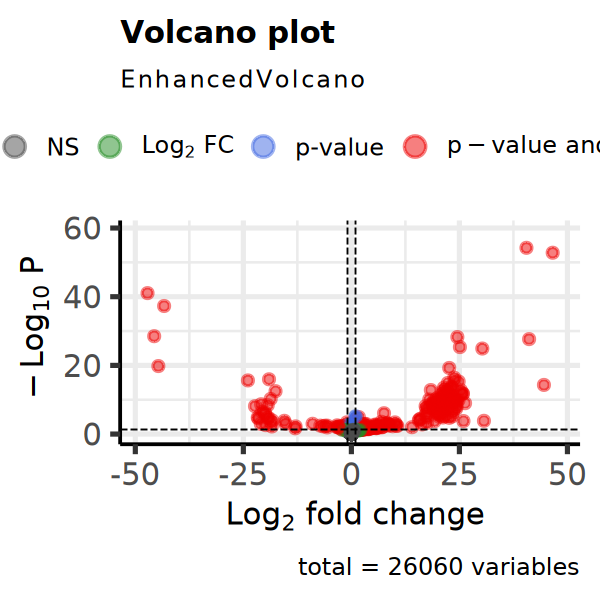

In [82]:
res.cb.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cb.cc)

EnhancedVolcano(res.cb.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cb.cc)

In [83]:
write.csv(res.cb.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/cb_cc.csv', row.names = FALSE)

### 3. Timing of Stress Exposure
How does GE change depending on when stress is experienced (when all oysters only experience stress once)?
- CH vs. HC
- CW vs. WC
- CB vs. BC

**CH vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 77, 0.3%
LFC < 0 (down)     : 67, 0.26%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.hypoxic vs hypoxic.control 
Wald test p-value: complete_trtmt control.hypoxic vs hypoxic.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435   -0.003824384 0.0552201 0.7757077  0.990107
LOC144621269  2097.061    0.001519266 0.0782830 0.6883318  0.988830
LOC111120925   132.085   -0.010994351 0.1718093 0.1165667  0.782951
LOC144621283   866.810   -0.011888282 0.0555296 0.3767417  0.940236
LOC144621276 12195.377   -0.037759760 0.0565159 0.0347012  0.596673
LOC111115920   171.873    0.000177913 0.0571426 0.9810132  1.000000

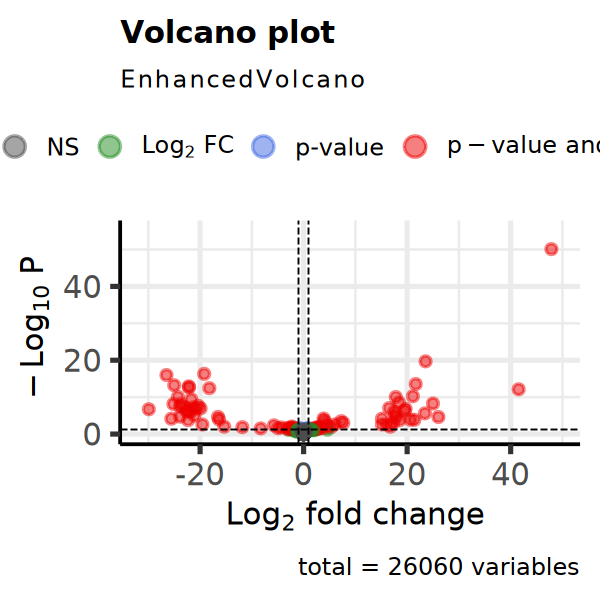

In [84]:
res.ch.hc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.ch.hc)

EnhancedVolcano(res.ch.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.ch.hc)

In [85]:
write.csv(res.ch.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/ch_hc.csv', row.names = FALSE)

**CW vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 158, 0.61%
LFC < 0 (down)     : 135, 0.52%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.warm vs warm.control 
Wald test p-value: complete_trtmt control.warm vs warm.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435     0.05107267  0.142653  0.569036  0.871337
LOC144621269  2097.061     0.03265414  0.217376  0.204777  0.638639
LOC111120925   132.085    -0.01385920  0.198023  0.540920  0.857762
LOC144621283   866.810    -0.00686695  0.142807  0.938926  0.987191
LOC144621276 12195.377    -0.09013675  0.122813  0.323050  0.737892
LOC111115920   171.873    -0.05227448  0.169579  0.426556  0.801300

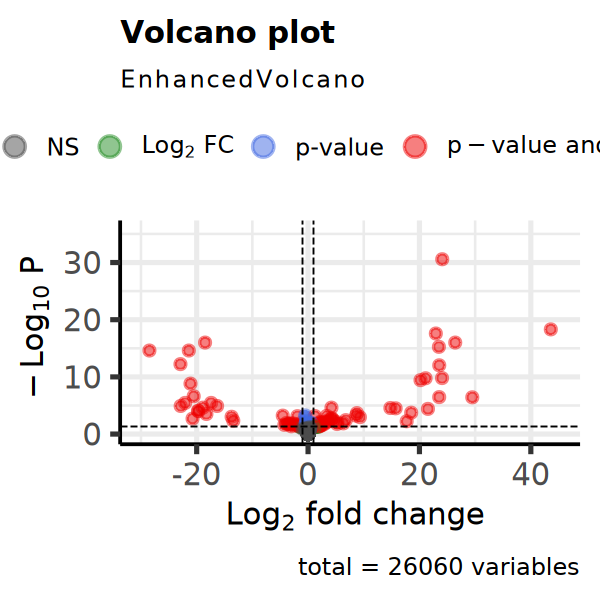

In [86]:
res.cw.wc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.cw.wc)

EnhancedVolcano(res.cw.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cw.wc)

In [87]:
write.csv(res.cw.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/cw_wc.csv', row.names = FALSE)

**CB vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 322, 1.2%
LFC < 0 (down)     : 157, 0.6%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.both vs both.control 
Wald test p-value: complete_trtmt control.both vs both.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  1949.435     0.04887478  0.127539 0.44801128  0.874644
LOC144621269  2097.061    -0.01253707  0.189730 0.56308587  0.917938
LOC111120925   132.085     0.23332970  0.953901 0.00516374  0.166940
LOC144621283   866.810    -0.00166476  0.122083 0.97874964  0.996588
LOC144621276 12195.377     0.05837788  0.110815 0.37962084  0.841712
LOC111115920   171.873     0.01283022  0.152129 0.79827745  0.967091

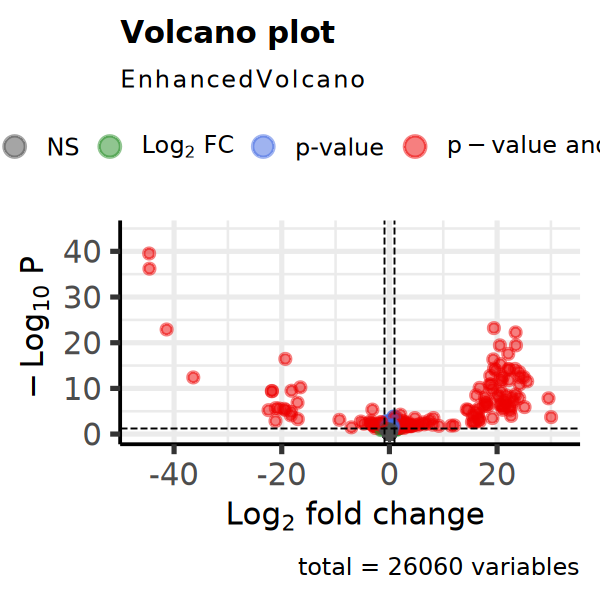

In [88]:
res.cb.bc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'both.control'), # BC is the "control"
                     type = 'ashr')

summary(res.cb.bc)

EnhancedVolcano(res.cb.bc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cb.bc)

In [89]:
write.csv(res.cb.bc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/cb_bc.csv', row.names = FALSE)

### 4. No stress vs. most stress
- CC vs. WW
- CC vs. HH
- CC vs. BB

**CC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 447, 1.7%
LFC < 0 (down)     : 82, 0.31%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt warm.warm vs control.control 
Wald test p-value: complete_trtmt warm.warm vs control.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  1949.435     0.01582355 0.0700677 0.43927033  0.922908
LOC144621269  2097.061     0.93115566 1.9289947 0.00253983  0.114932
LOC111120925   132.085    -0.00286659 0.1377673 0.78176664  0.982354
LOC144621283   866.810    -0.02525877 0.0710525 0.21952189  0.809584
LOC144621276 12195.377    -0.01191332 0.0669066 0.64369951  0.971983
LOC111115920   171.873     0.01124901 0.0768019 0.35474081  0.893767

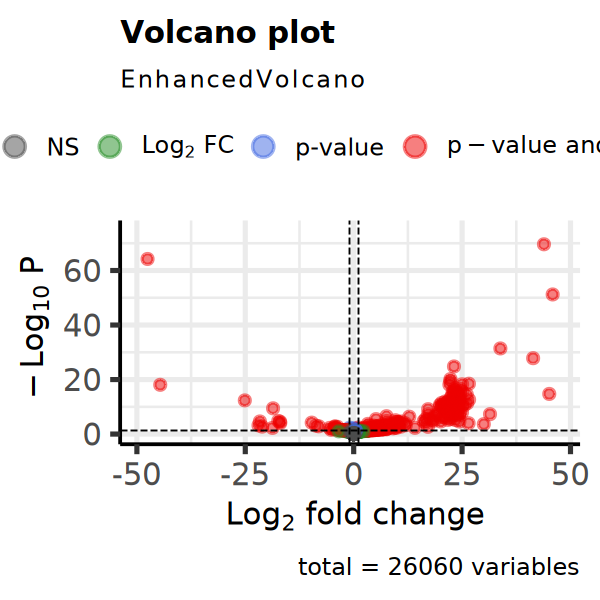

In [90]:
res.cc.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.ww)

EnhancedVolcano(res.cc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cc.ww)

In [91]:
write.csv(res.cc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/ww_cc.csv', row.names = FALSE)

**CC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 168, 0.64%
LFC < 0 (down)     : 105, 0.4%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt hypoxic.hypoxic vs control.control 
Wald test p-value: complete_trtmt hypoxic.hypoxic vs control.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435   -1.13704e-02 0.0713770 0.5756807  0.969421
LOC144621269  2097.061    1.46320e-02 0.1982237 0.0990705  0.722006
LOC111120925   132.085   -3.18074e-05 0.0938681 0.9947364  1.000000
LOC144621283   866.810    3.22440e-03 0.0709487 0.8732317  0.993919
LOC144621276 12195.377    7.00465e-03 0.0675039 0.7799394  0.985782
LOC111115920   171.873    7.16900e-03 0.0750312 0.5394503  0.960160

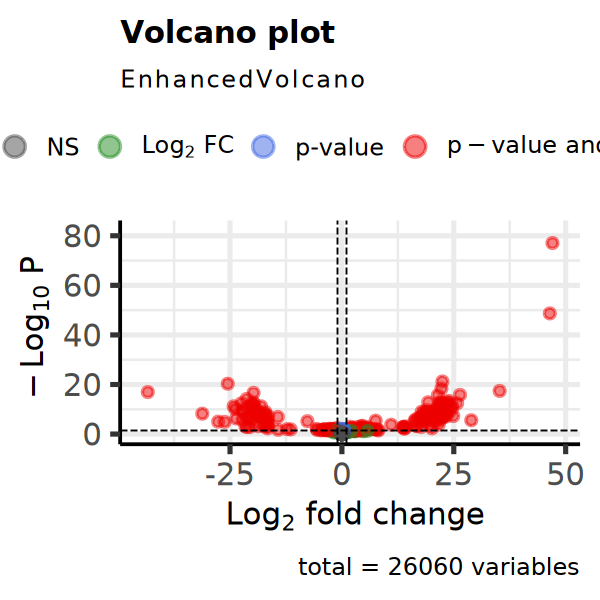

In [92]:
res.cc.hh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.hh)

EnhancedVolcano(res.cc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cc.hh)

In [93]:
write.csv(res.cc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/hh_cc.csv', row.names = FALSE)

**CC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 125, 0.48%
LFC < 0 (down)     : 562, 2.2%
outliers [1]       : 79, 0.3%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete trtmt control.control vs both.both 
Wald test p-value: complete trtmt control.control vs both.both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  1949.435   -0.010846306  0.118170 0.85318309  0.972451
LOC144621269  2097.061   -0.574046393  1.416606 0.00541724  0.141494
LOC111120925   132.085   -0.012669224  0.218847 0.61122139  0.900592
LOC144621283   866.810    0.007476253  0.118176 0.89838683  0.981566
LOC144621276 12195.377   -0.014976640  0.105577 0.81550189  0.961575
LOC111115920   171.873   -0.000658718  0.137362 0.98722552  0.996524

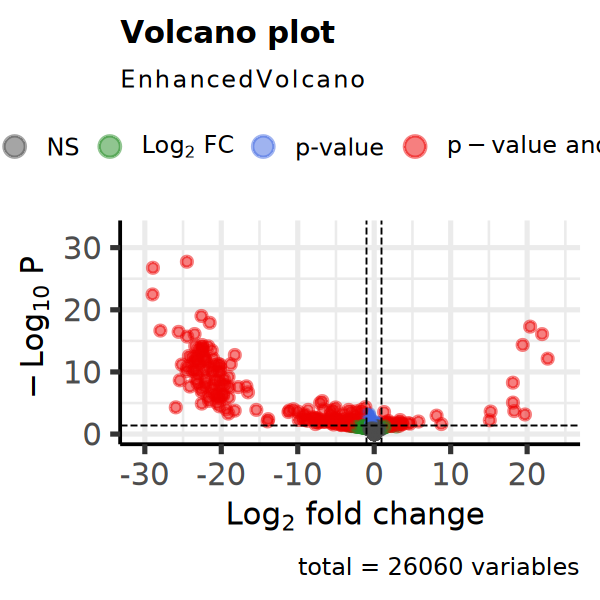

In [94]:
res.cc.bb <- lfcShrink(dds_rm, coef='complete_trtmt_control.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.cc.bb)

EnhancedVolcano(res.cc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cc.bb)

switch LFC direction so CC is the baseline (deseq recognizes as bb as the baseline rn)

In [95]:
cc.bb.df <- as.data.frame(res.cc.bb) %>% # create df
mutate(log2FoldChange = log2FoldChange * -1) # multiple by -1 to make pos to neg and vice versa 

# validate
head(res.cc.bb)
head(cc.bb.df)

log2 fold change (MMSE): complete trtmt control.control vs both.both 
Wald test p-value: complete trtmt control.control vs both.both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  1949.435   -0.010846306  0.118170 0.85318309  0.972451
LOC144621269  2097.061   -0.574046393  1.416606 0.00541724  0.141494
LOC111120925   132.085   -0.012669224  0.218847 0.61122139  0.900592
LOC144621283   866.810    0.007476253  0.118176 0.89838683  0.981566
LOC144621276 12195.377   -0.014976640  0.105577 0.81550189  0.961575
LOC111115920   171.873   -0.000658718  0.137362 0.98722552  0.996524

,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,1949.4353,0.010846306,0.1181696,0.853183094,0.9724506
LOC144621269,2097.0613,0.574046393,1.4166064,0.005417241,0.1414943
LOC111120925,132.0849,0.012669224,0.2188470,0.611221386,0.9005917
LOC144621283,866.8099,-0.007476253,0.1181756,0.898386832,0.9815658
LOC144621276,12195.3765,0.014976640,0.1055768,0.815501885,0.9615752
LOC111115920,171.8729,0.000658718,0.1373620,0.987225525,0.9965243


In [96]:
write.csv(cc.bb.df, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bb_cc.csv', row.names = FALSE)

### 5. Effect of initial exposure on response in later exposure
(also gets at the effect of priming to stress)

#### 5A. Matched stressors
Oyster is primed with a stress, and experiences the *same* stressor again
- HH vs. CH
- WW vs. CW
- BB vs. CB

**HH vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 92, 0.35%
LFC < 0 (down)     : 186, 0.71%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt hypoxic.hypoxic vs control.hypoxic 
Wald test p-value: complete_trtmt hypoxic.hypoxic vs control.hypoxic 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435    9.20752e-05 0.00777412 0.6974020  0.997507
LOC144621269  2097.061   -1.85740e-04 0.08036089 0.9632222  0.998665
LOC111120925   132.085    2.58272e-02 0.30523925 0.0975463  0.823539
LOC144621283   866.810    2.37116e-04 0.00961993 0.3898063  0.983572
LOC144621276 12195.377    8.59101e-04 0.01596840 0.0666226  0.761692
LOC111115920   171.873    1.07245e-04 0.01483231 0.8153729  0.997507

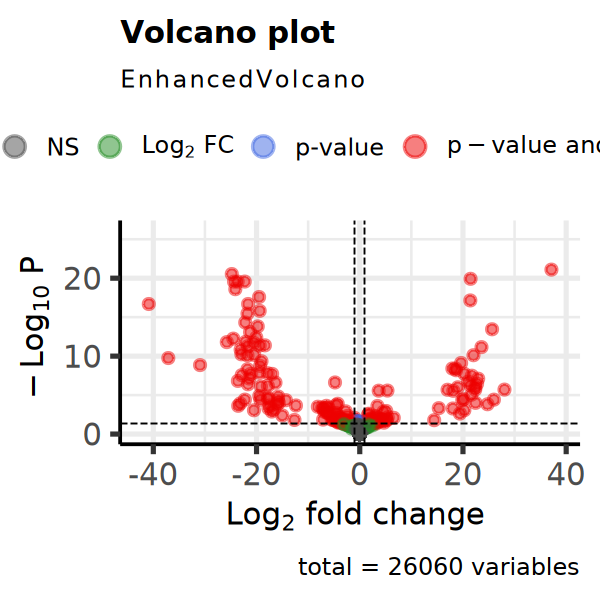

In [97]:
res.hh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.hh.ch)

EnhancedVolcano(res.hh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.hh.ch)

In [98]:
write.csv(res.hh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/hh_ch.csv', row.names = FALSE)

**WW vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 35, 0.13%
LFC < 0 (down)     : 29, 0.11%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt warm.warm vs control.warm 
Wald test p-value: complete_trtmt warm.warm vs control.warm 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435   -1.32359e-05 0.00629192  0.939514         1
LOC144621269  2097.061   -1.72540e-04 0.03222076  0.788049         1
LOC111120925   132.085    4.07285e-04 0.04019209  0.608130         1
LOC144621283   866.810   -1.57160e-04 0.00674159  0.386575         1
LOC144621276 12195.377   -4.41736e-05 0.00610840  0.844571         1
LOC111115920   171.873    6.21560e-05 0.00834680  0.674744         1

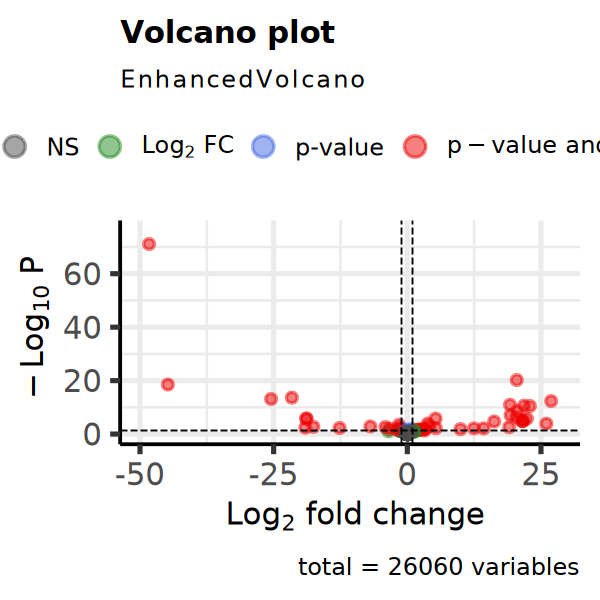

In [99]:
res.ww.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.ww.cw)

EnhancedVolcano(res.ww.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.ww.cw)

In [100]:
write.csv(res.ww.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/ww_cw.csv', row.names = FALSE)

**BB vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 37, 0.14%
LFC < 0 (down)     : 76, 0.29%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete trtmt control.both vs both.both 
Wald test p-value: complete trtmt control.both vs both.both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435   -1.36426e-05 0.00582111  0.927073  0.999112
LOC144621269  2097.061   -6.82425e-04 0.05121231  0.632952  0.999112
LOC111120925   132.085    4.69551e-04 0.05293336  0.762843  0.999112
LOC144621283   866.810    2.43593e-05 0.00584345  0.870350  0.999112
LOC144621276 12195.377    2.64567e-04 0.00672063  0.187529  0.977951
LOC111115920   171.873    9.79468e-05 0.01004837  0.619822  0.999112

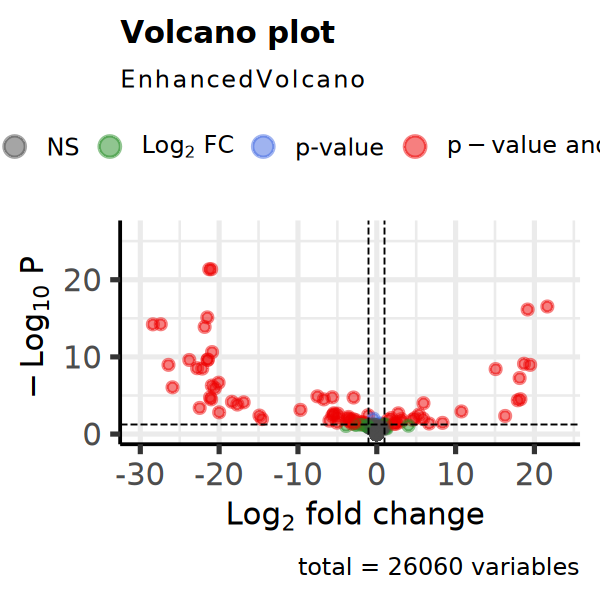

In [101]:
res.cb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_control.both_vs_both.both', # BB is the "control"
                       type = 'ashr')

summary(res.cb.bb)

EnhancedVolcano(res.cb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cb.bb)

In [102]:
write.csv(res.cb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/cb_bb.csv', row.names = FALSE)

#### 5B. Semi-matched priming: in context of later *single* stress
- CH vs. BH
- CW vs. BW

**CH vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 149, 0.57%
LFC < 0 (down)     : 253, 0.97%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt both.hypoxic vs control.hypoxic 
Wald test p-value: complete_trtmt both.hypoxic vs control.hypoxic 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435     0.02390190 0.0813666  0.369653  0.839455
LOC144621269  2097.061    -0.00843356 0.1555853  0.491751  0.881333
LOC111120925   132.085     0.02168169 0.2427604  0.212666  0.740754
LOC144621283   866.810    -0.03246628 0.0838921  0.230484  0.754174
LOC144621276 12195.377     0.02625837 0.0754042  0.409795  0.854367
LOC111115920   171.873     0.01798745 0.0929891  0.296113  0.802540

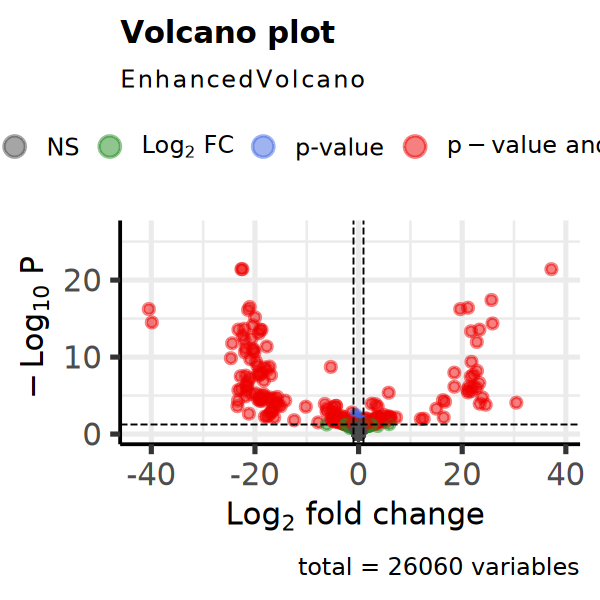

In [103]:
res.bh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.bh.ch)

EnhancedVolcano(res.bh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.bh.ch)

In [104]:
write.csv(res.bh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bh_ch.csv', row.names = FALSE)

**CW vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 45, 0.17%
LFC < 0 (down)     : 120, 0.46%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt both.warm vs control.warm 
Wald test p-value: complete_trtmt both.warm vs control.warm 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435   -0.005374402 0.0558039  0.695046  0.979489
LOC144621269  2097.061   -0.007905454 0.1335398  0.181867  0.818730
LOC111120925   132.085    0.004652286 0.1090635  0.343307  0.900754
LOC144621283   866.810   -0.008699503 0.0559061  0.524899  0.951295
LOC144621276 12195.377   -0.012368943 0.0543007  0.486055  0.943178
LOC111115920   171.873   -0.000400443 0.0577529  0.958151  0.998317

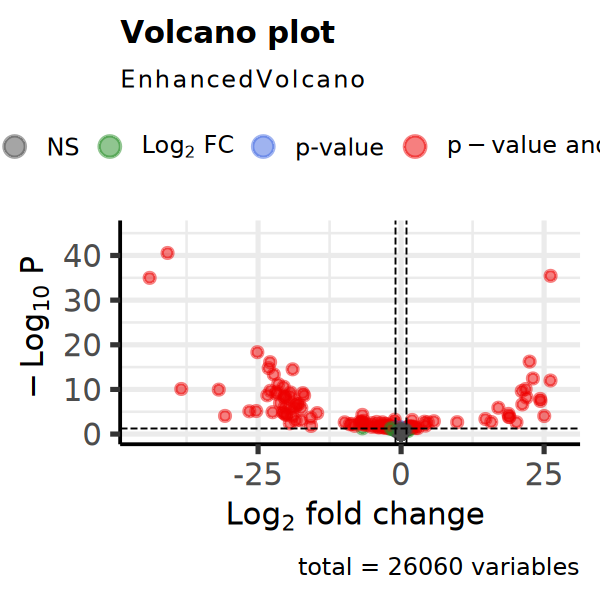

In [105]:
res.bw.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.bw.cw)

EnhancedVolcano(res.bw.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.bw.cw)

In [106]:
write.csv(res.bw.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bw_cw.csv', row.names = FALSE)

#### 5C. Semi-matched priming: in context of later *multiple* stress
- CB vs. WB
- CB vs. HB

**CB vs. WB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 243, 0.93%
LFC < 0 (down)     : 81, 0.31%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt warm.both vs control.both 
Wald test p-value: complete_trtmt warm.both vs control.both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435    7.92759e-05 0.00985015  0.849717  0.992272
LOC144621269  2097.061    2.54716e-03 0.12203462  0.781119  0.987298
LOC111120925   132.085    2.76854e-03 0.13563147  0.790740  0.988467
LOC144621283   866.810   -7.88555e-04 0.01765272  0.237784  0.855066
LOC144621276 12195.377   -3.80965e-04 0.00983488  0.367735  0.914795
LOC111115920   171.873    8.99452e-04 0.02841118  0.475573  0.948478

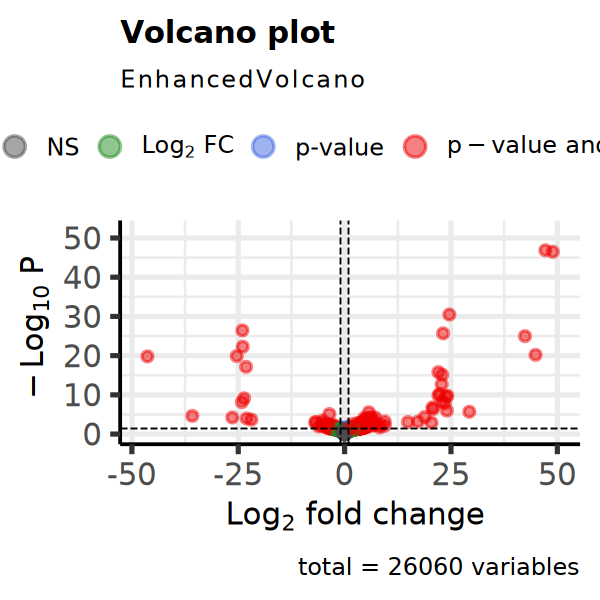

In [107]:
res.wb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.wb.cb)

EnhancedVolcano(res.wb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.wb.cb)

In [108]:
write.csv(res.wb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/wb_cb.csv', row.names = FALSE)

**CB vs. HB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 68, 0.26%
LFC < 0 (down)     : 46, 0.18%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt hypoxic.both vs control.both 
Wald test p-value: complete_trtmt hypoxic.both vs control.both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435   -1.19804e-04 0.00659865  0.509279         1
LOC144621269  2097.061    3.47047e-04 0.03893762  0.688755         1
LOC111120925   132.085   -8.50411e-05 0.03980359  0.928159         1
LOC144621283   866.810   -8.21444e-05 0.00645762  0.645817         1
LOC144621276 12195.377    4.00254e-05 0.00613012  0.860032         1
LOC111115920   171.873   -4.87683e-05 0.00844147  0.754004         1

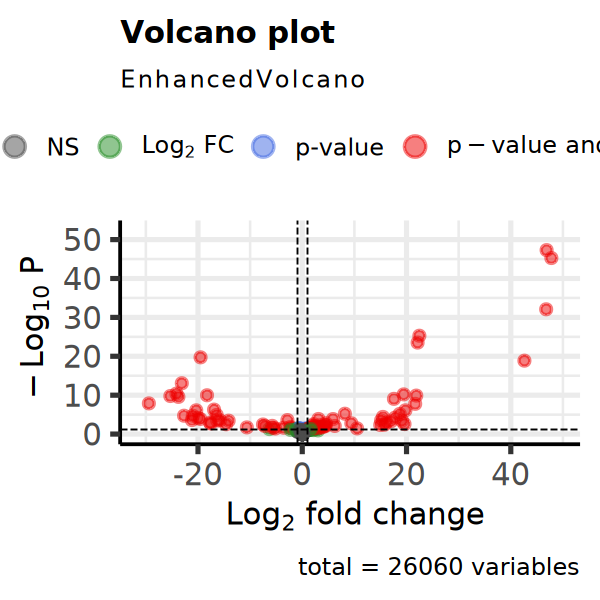

In [109]:
res.hb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.hb.cb)

EnhancedVolcano(res.hb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.hb.cb)

In [110]:
write.csv(res.hb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/hb_cb.csv', row.names = FALSE)

### 6. Effect of initial exposure on subsequent response to stress
Oysters all experience the same early stressor, but either return to that stressor or experience control conditions
- HC vs. HH
- WC vs. WW
- BB vs. BC

**HC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 150, 0.58%
LFC < 0 (down)     : 109, 0.42%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt hypoxic.control vs hypoxic.hypoxic 
Wald test p-value: complete_trtmt hypoxic.control vs hypoxic.hypoxic 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435   -0.002991885 0.0779814  0.906751  0.991452
LOC144621269  2097.061   -0.002534933 0.1120418  0.736611  0.974787
LOC111120925   132.085   -0.001203177 0.1151615  0.872602  0.988020
LOC144621283   866.810   -0.000434314 0.0779849  0.986418  0.999484
LOC144621276 12195.377    0.005675888 0.0740843  0.857626  0.985921
LOC111115920   171.873   -0.003806259 0.0825534  0.797843  0.981445

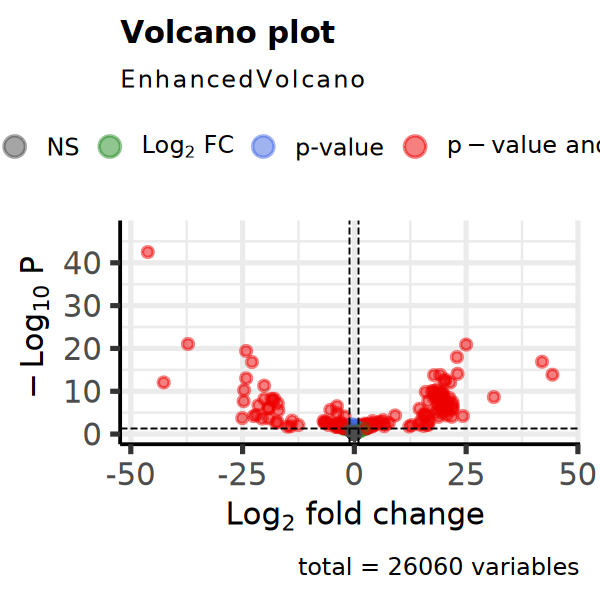

In [111]:
res.hc.hh <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.control', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hc.hh)

EnhancedVolcano(res.hc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.hc.hh)

In [112]:
write.csv(res.hc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/hc_hh.csv', row.names = FALSE)

**WC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 87, 0.33%
LFC < 0 (down)     : 102, 0.39%
outliers [1]       : 79, 0.3%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt warm.control vs warm.warm 
Wald test p-value: complete_trtmt warm.control vs warm.warm 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435    -0.03773820  0.131916  0.621552  0.895979
LOC144621269  2097.061    -0.02058507  0.187832  0.317688  0.749495
LOC111120925   132.085     0.00181554  0.175281  0.921359  0.982294
LOC144621283   866.810     0.07231361  0.132951  0.345891  0.767178
LOC144621276 12195.377     0.09538326  0.116418  0.236293  0.686312
LOC111115920   171.873     0.02033468  0.153716  0.707113  0.925419

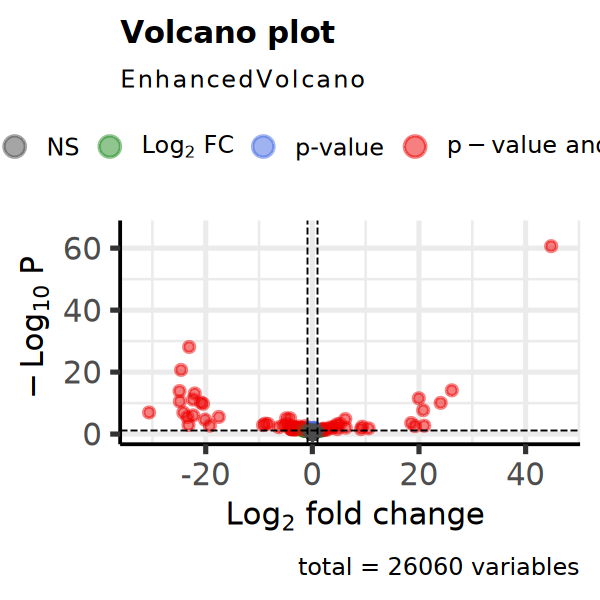

In [113]:
res.wc.ww <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.control', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.wc.ww)

EnhancedVolcano(res.wc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.wc.ww)

In [114]:
write.csv(res.wc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/wc_ww.csv', row.names = FALSE)

**BC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 76, 0.29%
LFC < 0 (down)     : 316, 1.2%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete trtmt both.control vs both.both 
Wald test p-value: complete trtmt both.control vs both.both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435    -0.02905030 0.0934431 0.3975210  0.901809
LOC144621269  2097.061     0.00140122 0.1353879 0.9021725  0.990604
LOC111120925   132.085    -0.19835316 0.9013663 0.0120533  0.278452
LOC144621283   866.810     0.00605795 0.0891481 0.8553403  0.987059
LOC144621276 12195.377     0.01419710 0.0812393 0.7054054  0.973496
LOC111115920   171.873     0.00490290 0.1017971 0.8277038  0.986374

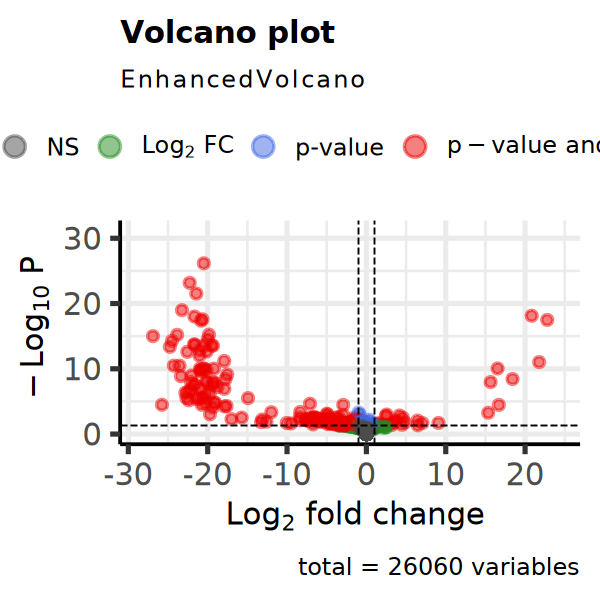

In [115]:
res.bc.bb <- lfcShrink(dds_rm, coef = 'complete_trtmt_both.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.bc.bb)

EnhancedVolcano(res.bc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.bc.bb)

In [116]:
write.csv(res.bc.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bc_bb.csv', row.names = FALSE)

### 7. Effect of initial single/multiple stress on response in ...
Is it better to be primed with a single stressor or multiple stressor, depending on the context of the future enviornment (single/multiple stressor)?

#### 7A. ...later *single* stress
Oyster is primed with either multiple or a single stressors, and then experiences only a sinlge stressor later
- BH vs. HH
- BW vs. WW

**BH vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 154, 0.59%
LFC < 0 (down)     : 180, 0.69%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt both.hypoxic vs hypoxic.hypoxic 
Wald test p-value: complete_trtmt both.hypoxic vs hypoxic.hypoxic 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435     0.01896834 0.0985714 0.6264665  0.939628
LOC144621269  2097.061    -0.00650185 0.1402294 0.5391385  0.922756
LOC111120925   132.085    -0.00399889 0.1395725 0.6938527  0.951239
LOC144621283   866.810    -0.07878297 0.1035327 0.0487155  0.539585
LOC144621276 12195.377    -0.04515149 0.0925121 0.3336105  0.853947
LOC111115920   171.873     0.01832871 0.1068029 0.4372833  0.892729

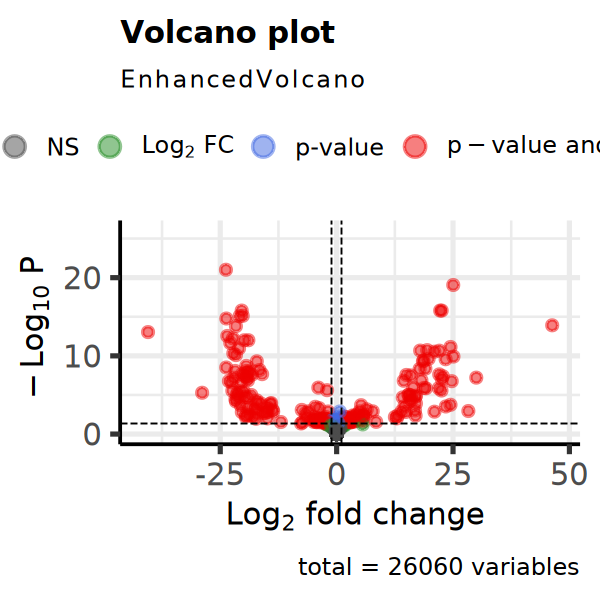

In [117]:
res.hh.bh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hh.bh)

EnhancedVolcano(res.hh.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.hh.bh)

In [118]:
write.csv(res.hh.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bh_hh.csv', row.names = FALSE)

**BW vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 60, 0.23%
LFC < 0 (down)     : 112, 0.43%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt both.warm vs warm.warm 
Wald test p-value: complete_trtmt both.warm vs warm.warm 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435    -0.00895990 0.0802172  0.751867  0.976201
LOC144621269  2097.061    -0.00875742 0.1320996  0.286338  0.855451
LOC111120925   132.085     0.00305204 0.1112342  0.663504  0.963875
LOC144621283   866.810     0.00649532 0.0802320  0.818172  0.982176
LOC144621276 12195.377    -0.01737659 0.0758794  0.616671  0.953653
LOC111115920   171.873    -0.00782392 0.0852042  0.636794  0.958475

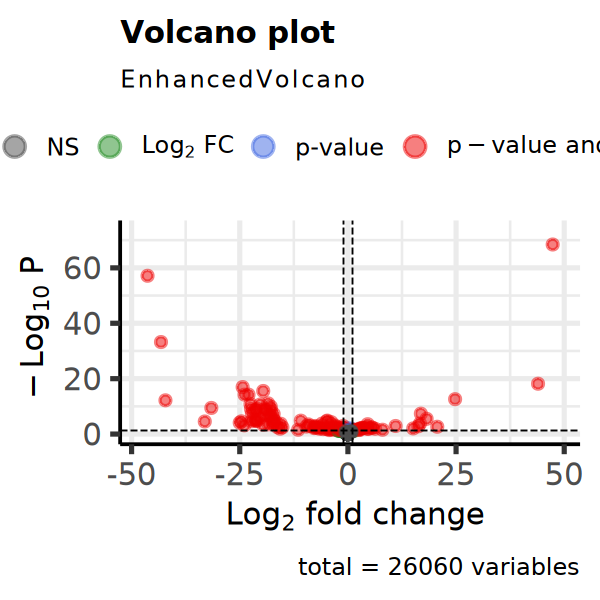

In [119]:
res.bw.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.bw.ww)

EnhancedVolcano(res.bw.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.bw.ww)

In [120]:
write.csv(res.bw.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bw_ww.csv', row.names = FALSE)

#### 7B. ...later *multiple* stressors
Oyster is primed with either multiple or a single stressors, and then experiences multiple stressors later
- HB vs. BB
- WB vs. BB

**HB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 52, 0.2%
LFC < 0 (down)     : 81, 0.31%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete trtmt hypoxic.both vs both.both 
Wald test p-value: complete trtmt hypoxic.both vs both.both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435   -2.23158e-04 0.00878312  0.452348  0.999809
LOC144621269  2097.061   -1.55278e-04 0.05559226  0.938603  0.999809
LOC111120925   132.085    4.93340e-04 0.06347625  0.832437  0.999809
LOC144621283   866.810   -8.31952e-05 0.00806629  0.766835  0.999809
LOC144621276 12195.377    5.91437e-04 0.00998403  0.135128  0.931303
LOC111115920   171.873    5.98414e-05 0.01211902  0.855399  0.999809

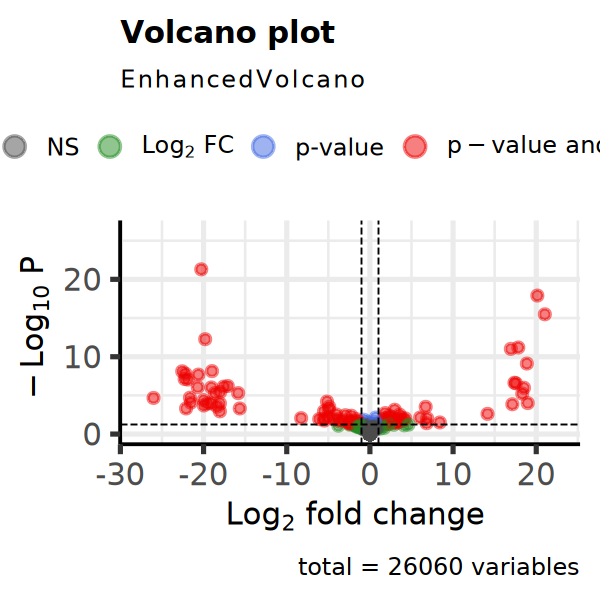

In [121]:
res.hb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_hypoxic.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.hb.bb)

EnhancedVolcano(res.hb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.hb.bb)

In [122]:
write.csv(res.hb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/hb_bb.csv', row.names = FALSE)

**WB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 67, 0.26%
LFC < 0 (down)     : 47, 0.18%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete trtmt warm.both vs both.both 
Wald test p-value: complete trtmt warm.both vs both.both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435    2.93104e-05 0.00824891  0.921956  0.999826
LOC144621269  2097.061   -4.61857e-04 0.06030868  0.841705  0.999826
LOC111120925   132.085    1.63457e-03 0.07726240  0.570648  0.999826
LOC144621283   866.810   -3.53014e-04 0.01035010  0.308897  0.992541
LOC144621276 12195.377    1.47351e-04 0.00771951  0.676564  0.999826
LOC111115920   171.873    7.81154e-04 0.02471924  0.226468  0.961449

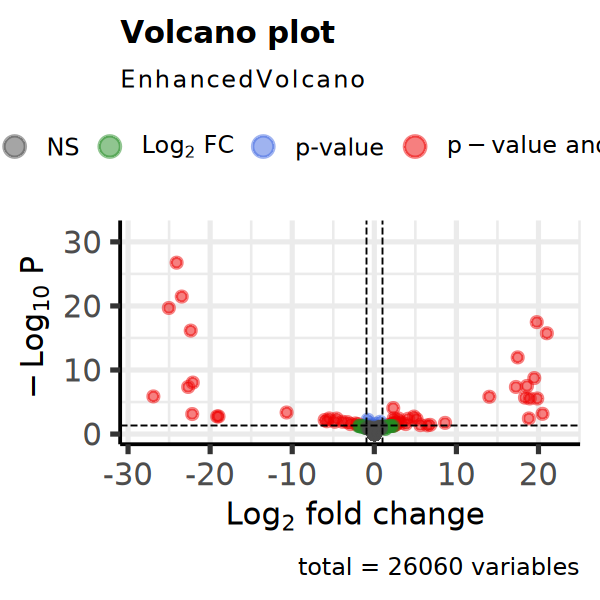

In [123]:
res.wb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_warm.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.wb.bb)

EnhancedVolcano(res.wb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.wb.bb)

In [124]:
write.csv(res.wb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/wb_bb.csv', row.names = FALSE)

### 8. Shared/Unique responses among stressors with ...

#### 8A. ...different *early* stressors
>can compare these with the phase 1 vs. phase 1 DEGs to see if there are similarities
- WC vs. HC: single early stress
- BC vs. HC: mulitple vs. single
- BC vs. WC: multiple vs. single

**WC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 62, 0.24%
LFC < 0 (down)     : 39, 0.15%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt warm.control vs hypoxic.control 
Wald test p-value: complete_trtmt warm.control vs hypoxic.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435    1.91980e-04 0.00716829  0.292297         1
LOC144621269  2097.061    8.42389e-04 0.05131974  0.475759         1
LOC111120925   132.085   -1.79123e-05 0.04271180  0.986923         1
LOC144621283   866.810   -8.43143e-05 0.00630446  0.616248         1
LOC144621276 12195.377    4.26163e-05 0.00586909  0.837533         1
LOC111115920   171.873    1.93105e-04 0.01181920  0.345894         1

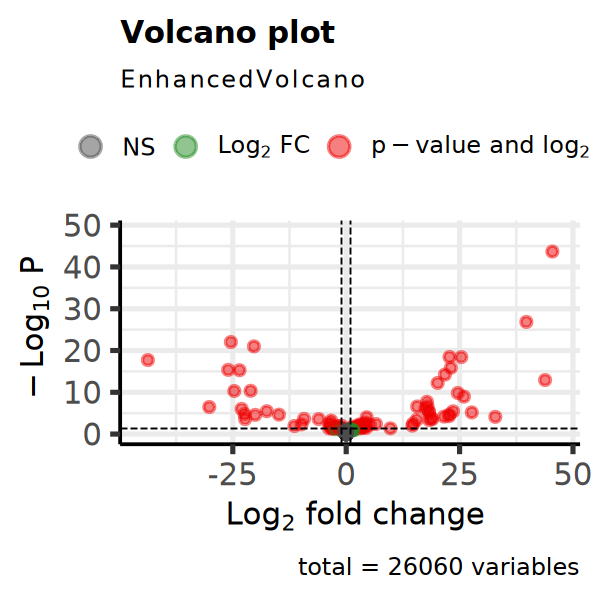

In [125]:
res.wc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.wc.hc)

EnhancedVolcano(res.wc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.wc.hc)

In [126]:
write.csv(res.wc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/wc_hc.csv', row.names = FALSE)

**BC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 48, 0.18%
LFC < 0 (down)     : 119, 0.46%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt both.control vs hypoxic.control 
Wald test p-value: complete_trtmt both.control vs hypoxic.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435    6.35246e-06 0.00610674 0.9676464         1
LOC144621269  2097.061    4.44456e-03 0.12364499 0.1290089         1
LOC111120925   132.085   -1.09714e-02 0.21305425 0.0660049         1
LOC144621283   866.810   -1.48601e-05 0.00611301 0.9243824         1
LOC144621276 12195.377    2.76746e-05 0.00585432 0.8885322         1
LOC111115920   171.873   -2.24082e-05 0.00830357 0.8802006         1

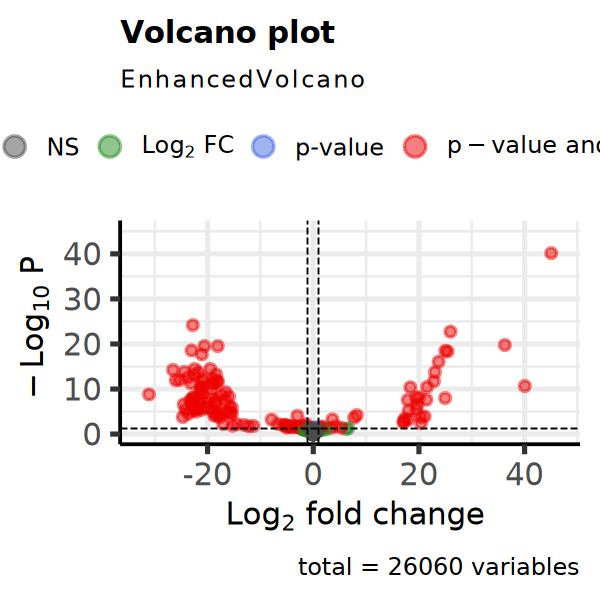

In [127]:
res.bc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.bc.hc)

EnhancedVolcano(res.bc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.bc.hc)

In [128]:
write.csv(res.bc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bc_hc.csv', row.names = FALSE)

**BC vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 58, 0.22%
LFC < 0 (down)     : 202, 0.78%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt both.control vs warm.control 
Wald test p-value: complete_trtmt both.control vs warm.control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1949.435   -2.14988e-04 0.00858363 0.3352589  0.999521
LOC144621269  2097.061    2.75856e-03 0.09317041 0.4019841  0.999521
LOC111120925   132.085   -2.34867e-02 0.30314648 0.0683359  0.805138
LOC144621283   866.810    7.39108e-05 0.00694523 0.7017046  0.999521
LOC144621276 12195.377   -1.15845e-05 0.00602533 0.9558578  0.999521
LOC111115920   171.873   -4.61663e-04 0.01968781 0.2939898  0.999521

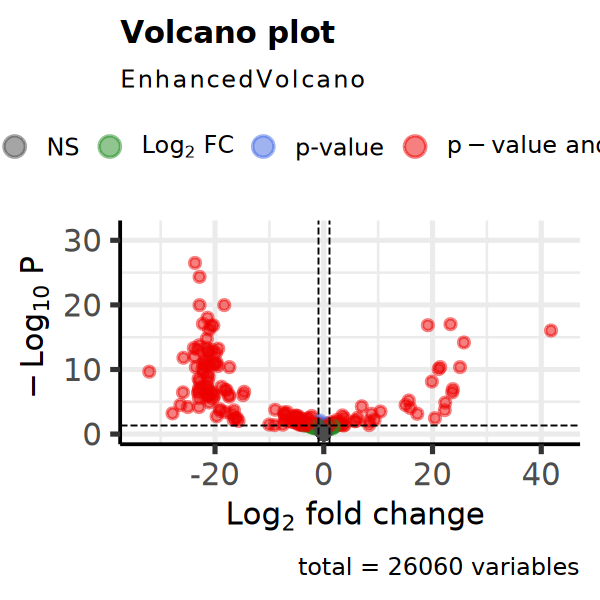

In [129]:
res.bc.wc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.bc.wc)

EnhancedVolcano(res.bc.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.bc.wc)

In [130]:
write.csv(res.bc.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bc_wc.csv', row.names = FALSE)

#### 8B. ...different *late* stressors
- CW vs. CH: single early stress
- CB vs. CH: mulitple vs. single
- CB vs. CW: multiple vs. single

**CW vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 138, 0.53%
LFC < 0 (down)     : 71, 0.27%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.warm vs control.hypoxic 
Wald test p-value: complete_trtmt control.warm vs control.hypoxic 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435     0.03880846 0.0730139 0.0564498  0.562680
LOC144621269  2097.061     0.02543521 0.2508476 0.1140890  0.688674
LOC111120925   132.085     0.00998277 0.1622630 0.3460424  0.866908
LOC144621283   866.810     0.00593852 0.0665132 0.7597298  0.971831
LOC144621276 12195.377     0.03297655 0.0649653 0.1839962  0.763774
LOC111115920   171.873     0.00140134 0.0704627 0.9017960  0.992745

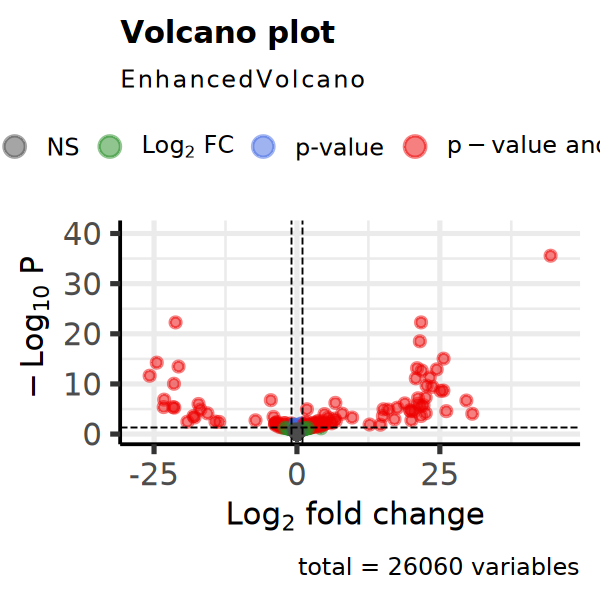

In [131]:
res.cw.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.warm', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cw.ch)

EnhancedVolcano(res.cw.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cw.ch)

In [132]:
write.csv(res.cw.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/cw_ch.csv', row.names = FALSE)

**CB vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 137, 0.53%
LFC < 0 (down)     : 153, 0.59%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.both vs control.hypoxic 
Wald test p-value: complete_trtmt control.both vs control.hypoxic 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  1949.435     0.04571920 0.0975488 0.26134588  0.813080
LOC144621269  2097.061     0.00780251 0.1510649 0.55886604  0.925728
LOC111120925   132.085     0.21506999 0.8867540 0.00996761  0.287105
LOC144621283   866.810     0.03050350 0.0963814 0.44948326  0.893897
LOC144621276 12195.377     0.17559584 0.1199945 0.00147151  0.115004
LOC111115920   171.873     0.00216619 0.1047577 0.93127135  0.991558

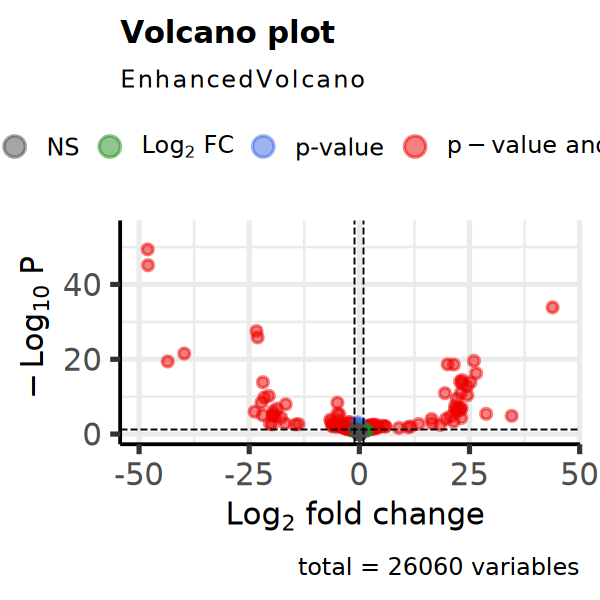

In [133]:
res.cb.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cb.ch)

EnhancedVolcano(res.cb.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cb.ch)

In [134]:
write.csv(res.cb.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/cb_ch.csv', row.names = FALSE)

**CB vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 117, 0.45%
LFC < 0 (down)     : 112, 0.43%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt control.both vs control.warm 
Wald test p-value: complete_trtmt control.both vs control.warm 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435   -0.025980848 0.0872160 0.4328951  0.892711
LOC144621269  2097.061   -0.012420409 0.1604208 0.3194625  0.850996
LOC111120925   132.085    0.029274402 0.2606729 0.1015323  0.682850
LOC144621283   866.810    0.014831859 0.0867283 0.6525521  0.947655
LOC144621276 12195.377    0.075340601 0.0850444 0.0640862  0.608117
LOC111115920   171.873   -0.000754814 0.0942540 0.9703773  0.996237

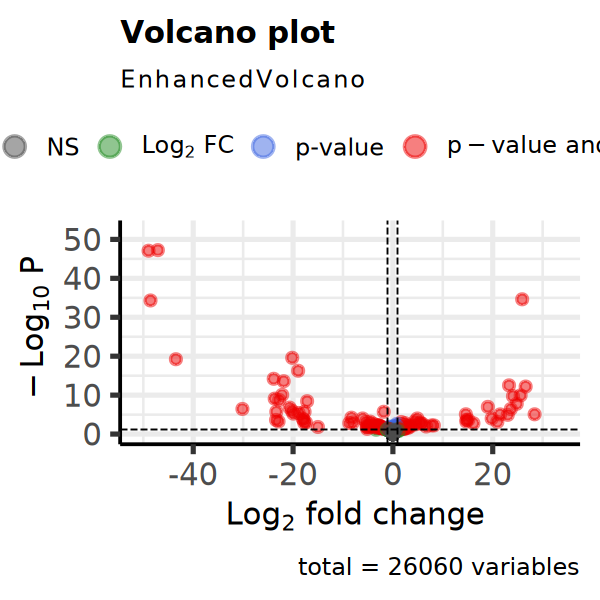

In [135]:
res.cb.cw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.cb.cw)

EnhancedVolcano(res.cb.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.cb.cw)

In [136]:
write.csv(res.cb.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/cb_cw.csv', row.names = FALSE)

### 9. Effect of the order of stressors
Does the order of when stress is experienced matter? Maybe one stressor is an informative cue for a later environmnet?
- WH vs. HW
- WB vs. BW
- HB vs. BH

**WH vs. HW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 59, 0.23%
LFC < 0 (down)     : 94, 0.36%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt warm.hypoxic vs hypoxic.warm 
Wald test p-value: complete_trtmt warm.hypoxic vs hypoxic.warm 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435    0.000531629 0.0510751  0.963099  0.996468
LOC144621269  2097.061   -0.003476744 0.0933158  0.457702  0.960973
LOC111120925   132.085   -0.000776452 0.0851164  0.856298  0.990430
LOC144621283   866.810    0.003729571 0.0513459  0.745977  0.984754
LOC144621276 12195.377   -0.003004239 0.0487599  0.834149  0.990430
LOC111115920   171.873   -0.001456989 0.0560491  0.839587  0.990430

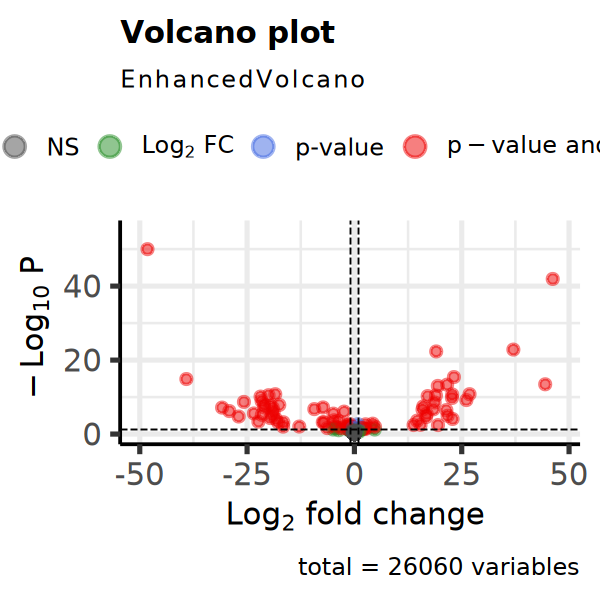

In [137]:
res.wh.hw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.hypoxic', 'hypoxic.warm'), # HW is the "control"
                     type = 'ashr')

summary(res.wh.hw)

EnhancedVolcano(res.wh.hw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.wh.hw)

In [138]:
write.csv(res.wh.hw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/wh_hw.csv', row.names = FALSE)

**WB vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 377, 1.4%
LFC < 0 (down)     : 129, 0.5%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt warm.both vs both.warm 
Wald test p-value: complete_trtmt warm.both vs both.warm 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435    -0.01039616  0.107903 0.8393416  0.968269
LOC144621269  2097.061     0.01272903  0.191607 0.5370164  0.871714
LOC111120925   132.085     0.02323657  0.244336 0.3392910  0.781858
LOC144621283   866.810    -0.00484426  0.107969 0.9245716  0.985371
LOC144621276 12195.377     0.09733740  0.100843 0.0994713  0.541614
LOC111115920   171.873     0.02437558  0.121969 0.4661353  0.845964

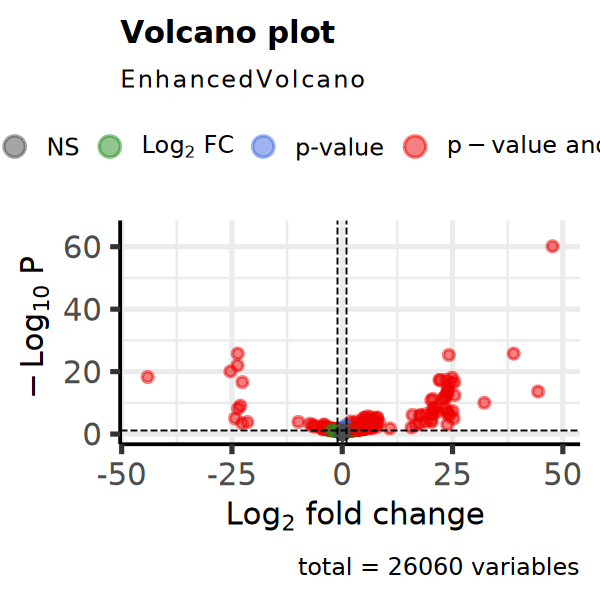

In [139]:
res.wb.bw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.both', 'both.warm'), # BW is the "control"
                     type = 'ashr')

summary(res.wb.bw)

EnhancedVolcano(res.wb.bw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.wb.bw)

In [140]:
write.csv(res.wb.bw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/wb_bw.csv', row.names = FALSE)

**HB vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 367, 1.4%
LFC < 0 (down)     : 112, 0.43%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt hypoxic.both vs both.hypoxic 
Wald test p-value: complete_trtmt hypoxic.both vs both.hypoxic 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  1949.435     -0.0265323  0.117963  0.648751  0.928127
LOC144621269  2097.061      0.0491718  0.341534  0.103804  0.551634
LOC111120925   132.085      0.0252336  0.247757  0.259416  0.735233
LOC144621283   866.810      0.0875376  0.121281  0.138788  0.609436
LOC144621276 12195.377      0.1610643  0.113973  0.017507  0.287696
LOC111115920   171.873     -0.0490446  0.137030  0.207622  0.691054

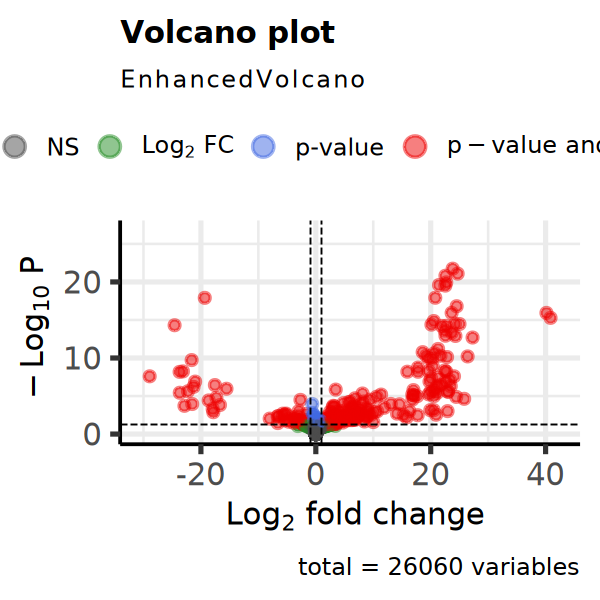

In [141]:
res.hb.bh <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'hypoxic.both', 'both.hypoxic'), # BH is the "control"
                     type = 'ashr')

summary(res.hb.bh)

EnhancedVolcano(res.hb.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.hb.bh)

In [142]:
write.csv(res.hb.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/hb_bh.csv', row.names = FALSE)

## 4. isolated treatment pairwise comparisons
looking at the effects of temperature and DO in an isolated manner

#### phase 1 temp
ambient vs. warm

regardless of phase 2 treatments or phase 1 DO

In [ ]:
design(dds_rm) <- ~ Phase1_temp
dds_p1temp <- DESeq(dds_rm)

In [ ]:
vst_temp.p1 <- vst(dds_p1temp, blind = FALSE)
head(vst_temp.p1)

In [ ]:
write.csv(assay(vst_temp.p1), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/vst_p1temp.p2.csv')

In [ ]:
p1_temp.res <- lfcShrink(dds_p1temp, contrast = c('Phase1_temp', 'warm', 'ambient'),
                     type = 'ashr')

summary(p1_temp.res)

EnhancedVolcano(p1_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_temp.res <- merge(p1_temp.res, counts(dds_p1temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_temp.res)[1] <- 'Gene'

head(p1_temp.res)

In [ ]:
as.data.frame(p1_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 14 DEGs

In [ ]:
write.csv(p1_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_temp.csv', row.names = FALSE)

#### phase 1 DO
normoxic vs. hypoxic

In [ ]:
design(dds_rm) <- ~ Phase1_DO
dds_p1DO <- DESeq(dds_rm)

In [ ]:
vst_DO.p1 <- vst(dds_p1DO, blind = FALSE)
head(vst_DO.p1)

In [ ]:
write.csv(assay(vst_DO.p1), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/vst_p1DO.p2.csv')

In [ ]:
p1_DO.res <- lfcShrink(dds_p1DO, contrast = c('Phase1_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p1_DO.res)

EnhancedVolcano(p1_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_DO.res <- merge(p1_DO.res, counts(dds_p1DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_DO.res)[1] <- 'Gene'

head(p1_DO.res)

a couple more DEGs, but still not a ton - to be expected, since we think GE is more short term

In [ ]:
as.data.frame(p1_DO.res) %>%
filter(abs(log2FoldChange) >= 1 & padj <= 0.05) %>%
dim()

# 12 DEGs

In [ ]:
write.csv(p1_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_DO.csv', row.names = FALSE)

#### phase 2 temp
ambient vs. warm

regardless of phase 1 treatments or phase 2 DO

In [ ]:
design(dds_rm) <- ~ Phase2_temp
dds_p2temp <- DESeq(dds_rm)

In [ ]:
vst_temp.p2 <- vst(dds_p2temp, blind = FALSE)
head(vst_temp.p2)

In [ ]:
write.csv(assay(vst_temp.p2), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/vst_p2temp.p2.csv')

In [ ]:
p2_temp.res <- lfcShrink(dds_p2temp, contrast = c('Phase2_temp', 'warm', 'ambient'), 
                     type = 'ashr')

summary(p2_temp.res)

EnhancedVolcano(p2_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_temp.res <- merge(p2_temp.res, counts(dds_p2temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_temp.res)[1] <- 'Gene'

head(p2_temp.res)

In [ ]:
as.data.frame(p2_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 80 DEGs!

In [ ]:
write.csv(p2_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_temp.csv', row.names = FALSE)

#### phase 2 DO
normoxic vs. hypoxic

regardless of phase 1 treatments or phase 2 temperatures

In [ ]:
design(dds_rm) <- ~ Phase2_DO
dds_p2DO <- DESeq(dds_rm)

In [ ]:
vst_DO.p2 <- vst(dds_p2DO, blind = FALSE)
head(vst_DO.p2)

In [ ]:
write.csv(assay(vst_DO.p2), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/vst_p2DO.p2.csv')

In [ ]:
p2_DO.res <- lfcShrink(dds_p2DO, contrast = c('Phase2_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p2_DO.res)

EnhancedVolcano(p2_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_DO.res <- merge(p2_DO.res, counts(dds_p2DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_DO.res)[1] <- 'Gene'

head(p2_DO.res)

In [ ]:
as.data.frame(p2_DO.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 29 DEGs!

In [ ]:
write.csv(p2_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_DO.csv', row.names = FALSE)

## nMDS of only significant DEGs
 

### DEGs from pairwise comparisons

In [ ]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs',
    full.names = TRUE
    )

names(files) <- gsub('DEG_', '', tools::file_path_sans_ext(basename(files)))
geneList <- lapply(files, read.csv)
names(geneList)

In [ ]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 1799 total DEGs
head(all_degs)

In [ ]:
# create vst matrix
vsd <- vst(dds_rm, blind = FALSE)

# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 1799 total DEGs kept
head(degs_vsd) 

In [ ]:
# calculate sample distances
sample_dists.deg <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists.deg)

# calculate MDS value from distance matrix
mdsData.deg <- data.frame(cmdscale(sample_dists.deg))
mds.deg <- cbind(mdsData.deg, as.data.frame(colData(vsd))) # combine with sample data
head(mds.deg)

#### p2 temp and DO

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase2_temp, shape = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 Temp',
    shape = 'Phase 2 DO',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p2 temp

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase2_temp)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 Temp',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p2 DO

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Dark2') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 DO',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p1 temp and DO

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 Temp',
    shape = 'Phase 1 DO',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p1 temp

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase1_temp)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 Temp',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p1 DO

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase1_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Dark2') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 DO',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### permanova for DEGs

In [ ]:
adonis2(sample_dists.deg ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

when only considering DEGs identified in all pairwise comparisons, only phase 2 temperature is significantly affecting gene expression profiles. this is interesting bc when I first did this with all genes, we saw a significant effect of phase 2 temp *and* DO (and the interaction of those two). so only seeing phase 2 temp and not DO suggests to me that most of the DEGs are identified due to temperature stress, and not so much bc of DO stress.

there's an *almost* significant term, Phase1_DO:Phase2_temp:Phase2:DO which is interesting! I've never seen a 3 way interaction come out before - so this means the effect of those individually rely on the value of each other?